# Workshop 2 — Machine Learning · Regresión: Flight Price Prediction

**Unidad 2 — Pipelines, entrenamiento, comparación de modelos y validación cruzada**

**Curso:** Fundamentos de Aprendizaje Automático — Ingeniería de Sistemas — EAFIT — 2026-2
**Profesor:** Yomin Estiven Jaramillo Múnera

**Responsable de esta parte:** `Jose Alejandro Jimenez` — **Fase 1 completa (puntos 1 a 10)**

**Dataset:** Flight Price Prediction — [Kaggle](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction)
**Archivo fuente:** `data/vuelos/Clean_Dataset.csv`
**Variable objetivo:** `price` (rupias indias, INR) — **regresión supervisada**

---

## Alcance de este notebook

Este notebook desarrolla la **Fase 1 — EDA, limpieza y preprocesamiento** del workshop, punto por punto:

| Punto | Tema |
|---|---|
| 1 | Documentación del dataset, problema de negocio y variable objetivo |
| 2 | Carga, `head()`/`tail()`, `.shape`, `.info()` y diccionario de datos |
| 3 | `.describe()` e interpretación de estadísticos |
| 4 | Valores nulos por columna y estrategia de imputación |
| 5 | Identificación y eliminación de duplicados |
| 6 | Inconsistencias de formato en columnas categóricas |
| 7 | Detección de outliers con el criterio IQR |
| 8 | Gráficas de EDA con interpretación y recomendación |
| 9 | Técnica de codificación por variable categórica |
| 10 | Necesidad y técnica de escalamiento de las numéricas |

Cada punto va acompañado de la celda de justificación que exige el enunciado: no basta con ejecutar el código, hay que sustentar por qué se tomó cada decisión.

Las fases 2 a 8 (partición train/validation/test, pipelines con `ColumnTransformer`, entrenamiento y comparación de los cinco modelos de regresión, métricas, evaluación en test, validación cruzada y conclusiones) quedan a cargo del resto del equipo y se apoyan directamente en la especificación de preprocesamiento que se define aquí en los puntos 9 y 10.

## Cómo reproducir este notebook

```
python -m venv .venv
source .venv/bin/activate        # Linux / macOS
.\.venv\Scripts\Activate.ps1     # Windows
pip install -r requirements.txt
jupyter lab
```

El notebook se ejecuta de arriba hacia abajo. La ruta del CSV es relativa a esta carpeta (`talleres/workshop2-ml/`), así que hay que abrirlo desde aquí. Los CSV no están versionados en el repositorio; el README de la carpeta indica cómo descargarlos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110

RUTA = "data/vuelos/Clean_Dataset.csv"

print("Versiones del entorno")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  seaborn     {sns.__version__}")


Versiones del entorno
  pandas      3.0.5
  numpy       2.5.1
  seaborn     0.13.2


## Punto 1 — Descripción del problema de negocio y variable objetivo

### El contexto

El conjunto de datos *Flight Price Prediction* recoge tarifas aéreas domésticas de India obtenidas por raspado del portal de venta de tiquetes **Ease My Trip**. La recolección abarca una ventana de aproximadamente cincuenta días, entre el **11 de febrero y el 31 de marzo de 2022**, y se restringe a los vuelos que conectan las **seis metrópolis más grandes del país**: Delhi, Mumbai, Bangalore, Kolkata, Hyderabad y Chennai. Estas seis ciudades aparecen tanto como origen como destino, de modo que el conjunto cubre las treinta rutas posibles entre ellas.

Conviene aclarar de entrada que la publicación original en Kaggle incluye tres archivos: `economy.csv` y `business.csv`, que son los datos crudos tal como fueron raspados y separados por cabina, y `Clean_Dataset.csv`, que consolida y tabula ambos en una sola tabla con esquema uniforme. Este último es el archivo que utilizamos aquí, y de ahí que la clase de cabina aparezca como una columna más (`class`) y no como dos ficheros distintos.

### Qué representa cada fila

Cada registro **no** es un vuelo, sino una **oferta de tarifa observada**: el precio que el portal mostraba para un vuelo concreto (identificado por su código en `flight`), en una cabina concreta, cuando la consulta se hizo faltando `days_left` días para la salida. Esto es importante porque significa que un mismo vuelo físico aparece varias veces en la tabla, una por cada día de antelación en el que fue consultado y por cada cabina disponible. El precio cambia entre esas observaciones aunque el vuelo sea el mismo, y precisamente esa variación es el fenómeno que interesa modelar.

### Por qué el precio no es fijo

La industria aerocomercial opera bajo esquemas de **pricing dinámico** (o *revenue management*): la aerolínea no publica un precio único por trayecto, sino que ajusta continuamente la tarifa según la ocupación esperada, la demanda residual y el tiempo que falta para el despegue. En la práctica, el precio que ve un comprador depende de al menos cinco factores que este conjunto de datos captura de forma explícita:

1. **Anticipación de compra** (`days_left`). Comprar con semanas de anticipación no cuesta lo mismo que comprar el día anterior; las tarifas suelen escalar de forma abrupta en los últimos días porque los asientos que quedan se reservan para el viajero de última hora, típicamente corporativo y menos sensible al precio.
2. **Clase o cabina** (`class`). Economy y Business son productos comercialmente distintos, con estructuras de costo y márgenes que no tienen nada que ver entre sí.
3. **Aerolínea** (`airline`). Un operador de bajo costo como AirAsia o SpiceJet y una aerolínea de servicio completo como Vistara o Air India compiten en segmentos diferentes, con políticas tarifarias propias.
4. **Ruta** (`source_city`, `destination_city`). La distancia, el volumen de tráfico y el nivel de competencia en cada par de ciudades condicionan el rango de precios factible.
5. **Escalas y horario** (`stops`, `departure_time`, `arrival_time`, `duration`). Un itinerario directo en franja horaria cómoda se vende más caro que uno con dos escalas y una espera larga en un aeropuerto intermedio.

### Variable objetivo

La variable objetivo es **`price`**: el precio del tiquete expresado en **rupias indias (INR)**. Es una variable **numérica continua** —aunque el archivo la almacene como entero, porque las tarifas se redondean a la rupia—, de manera que el problema se plantea como una tarea de **aprendizaje supervisado de regresión**. Todas las demás columnas actúan como variables predictoras, con la salvedad del índice residual que se comenta en el punto 2.

### Pregunta de negocio

La pregunta que se busca responder es: **¿cuánto costará un tiquete aéreo dadas las condiciones de la compra —ruta, aerolínea, cabina, número de escalas, horario y días de antelación— y cuáles de esos factores explican mejor la variación del precio?**

Responderla tiene valor por dos vías. Para el viajero o para un comparador de tarifas, permite estimar si una oferta está por encima o por debajo de lo esperable y sugerir el momento adecuado para comprar. Para la aerolínea o la agencia, permite entender la estructura de precios del mercado, contrastar la propia política tarifaria con la de la competencia y detectar rutas o franjas donde el precio se aparta de lo que el resto del mercado sostiene.


## Punto 2 — Carga del dataset, exploración estructural y diccionario de datos

Cargamos el archivo con `pandas` y revisamos primero sus dimensiones, para tener una idea del volumen con el que vamos a trabajar antes de mirar el contenido.


In [2]:
df = pd.read_csv(RUTA)

filas, columnas = df.shape
print(f"Filas: {filas:,}")
print(f"Columnas: {columnas}")
print(f"Dimensiones (shape): {df.shape}")


Filas: 300,153
Columnas: 12
Dimensiones (shape): (300153, 12)


El conjunto tiene **300.153 filas y 12 columnas**, un tamaño cómodo: suficientemente grande para que las estimaciones sean estables y para permitir una partición honesta en entrenamiento y prueba, y suficientemente pequeño para trabajarlo en memoria sin necesidad de procesamiento distribuido.

Veamos ahora las primeras y las últimas filas. Mirar las dos puntas y no solo la cabecera es una precaución barata: permite detectar filas de totales al final del archivo, bloques ordenados que delaten un sesgo en la exportación, o cambios de formato a mitad de tabla.


In [3]:
display(df.head(5))


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
display(df.tail(5))


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


Se aprecia de inmediato un detalle: el archivo está **ordenado**, no aleatorizado. Las primeras filas mezclan tres aerolíneas —SpiceJet, SpiceJet, AirAsia, Vistara y Vistara— pero todas salen de Delhi en clase Economy con `days_left = 1`, mientras que las últimas son de Vistara en Business con `days_left = 49`. Es decir, el archivo viene ordenado por `class` y, dentro de cada clase, por `days_left`. Esto no es un problema de calidad de los datos, pero sí es una advertencia importante para más adelante: **la partición en entrenamiento y prueba tendrá que hacerse con barajado**, porque un corte secuencial dejaría prácticamente toda la clase Business fuera del conjunto de entrenamiento.

Revisamos ahora los tipos de dato y la presencia de nulos con `.info()`.


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


De la salida de `.info()` se desprenden tres observaciones:

- **No hay valores nulos.** Las doce columnas reportan 300.153 valores no nulos, es decir, la tabla está completa. Esto es coherente con que `Clean_Dataset.csv` sea una versión ya consolidada de los archivos crudos.
- **Los tipos son los esperados.** Ocho columnas son de tipo texto (`object`, o `str` según la versión de pandas), `duration` es `float64`, y `days_left`, `price` y el índice residual son `int64`. Ninguna variable numérica quedó leída como texto, que es el error de carga más habitual.
- **Aparece una columna `Unnamed: 0`** que no corresponde a ningún atributo del negocio.

### Diccionario de datos

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Unnamed: 0` | Entero (`int64`) | Índice residual generado al exportar el CSV con el índice de pandas incluido. Toma los valores 0 a 300.152 de forma consecutiva y no aporta ninguna información sobre el vuelo ni sobre el precio. |
| `airline` | Categórica nominal (texto) | Aerolínea que opera el vuelo. Seis operadores distintos: Vistara, Air_India, Indigo, GO_FIRST, AirAsia y SpiceJet. |
| `flight` | Categórica nominal (texto) | Código identificador del vuelo, con el formato prefijo de aerolínea más número (por ejemplo `SG-8709` o `UK-706`). Presenta 1.561 valores únicos y cada código pertenece a una sola aerolínea, de modo que la información que aporta está en buena medida contenida en `airline`. |
| `source_city` | Categórica nominal (texto) | Ciudad de origen del trayecto. Seis valores: Delhi, Mumbai, Bangalore, Kolkata, Hyderabad y Chennai. |
| `departure_time` | Categórica ordinal (texto) | Franja horaria de salida, agrupada en seis bloques: Early_Morning, Morning, Afternoon, Evening, Night y Late_Night. |
| `stops` | Categórica ordinal (texto) | Número de escalas del itinerario, codificado como `zero`, `one` y `two_or_more`. |
| `arrival_time` | Categórica ordinal (texto) | Franja horaria de llegada, con las mismas seis categorías que `departure_time`. |
| `destination_city` | Categórica nominal (texto) | Ciudad de destino del trayecto. Mismas seis ciudades que en `source_city`. |
| `class` | Categórica ordinal (texto) | Clase o cabina del tiquete. Dos valores: Economy y Business. |
| `duration` | Numérica continua (`float64`) | Duración total del viaje en horas, incluyendo el tiempo de espera en las escalas. |
| `days_left` | Numérica discreta (`int64`) | Días de antelación entre la fecha en que se consultó la tarifa y la fecha del vuelo. Va de 1 a 49. |
| `price` | Numérica continua (`int64`) | **Variable objetivo.** Precio del tiquete en rupias indias (INR). |

### Clasificación de las variables

**Numéricas (3):** `duration`, `days_left` y `price`. A ellas se suma técnicamente `Unnamed: 0`, que es un entero pero no una variable en sentido estadístico.

**Categóricas (8):** `airline`, `flight`, `source_city`, `departure_time`, `stops`, `arrival_time`, `destination_city` y `class`.

Dentro de las categóricas conviene distinguir dos grupos, porque la codificación que reciban más adelante depende de ello:

- **Con orden natural (ordinales):** `stops` (`zero` < `one` < `two_or_more`) y `class` (Economy < Business en nivel de servicio y de precio). Ambas admiten una codificación ordinal que preserva ese orden con una sola columna. Las franjas horarias `departure_time` y `arrival_time` son un caso intermedio: tienen un orden cronológico dentro del día, pero ese orden es **cíclico** (Late_Night vuelve a conectar con Early_Morning), de modo que tratarlas como ordinales lineales impondría una relación que no se sostiene; las manejaremos como nominales.
- **Sin orden natural (nominales):** `airline`, `flight`, `source_city` y `destination_city`, además de las dos franjas horarias por lo recién dicho. Requieren codificación tipo *one-hot* o equivalente. El caso de `flight` merece atención aparte por su alta cardinalidad —1.561 categorías—, que haría inviable una expansión *one-hot* directa.

Finalmente, sobre `Unnamed: 0`: es un artefacto de exportación sin contenido informativo y **será eliminada en el bloque de limpieza**, donde se documenta la decisión junto con las demás verificaciones de calidad.


## Punto 3 — Estadísticos descriptivos de las variables numéricas

Aplicamos `.describe()` sobre las columnas numéricas para obtener el resumen de tendencia central, dispersión y cuartiles.


In [6]:
display(df.describe())


,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


La lectura de `price` en la tabla anterior deja una señal que no se puede pasar por alto, así que la desglosamos por clase de cabina antes de interpretar.


In [7]:
display(df.groupby("class")["price"].describe())


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.342383,3743.519517,1105.0,4173.0,5772.0,7746.0,42349.0


In [8]:
# Asimetría de las variables numéricas: confirma la lectura de los cuartiles
display(df[["duration", "days_left", "price"]].skew().to_frame("asimetría"))


,asimetría
duration,0.602899
days_left,-0.035464
price,1.061377


### Interpretación

**1. La media de `price` casi triplica su mediana, lo que revela una distribución fuertemente asimétrica a la derecha.**

La media del precio es de **20.889,66 INR** mientras que la mediana es de **7.425 INR**. Una diferencia de ese tamaño solo puede producirse si existe una cola larga de tarifas muy altas que arrastra el promedio hacia arriba, mientras la mitad de los registros permanece muy por debajo. El coeficiente de asimetría lo confirma: **1,061**, claramente positivo.

Ahora bien, lo que verdaderamente llama la atención no es la asimetría en sí, sino **el comportamiento de los cuartiles**. El primer cuartil está en 4.783 INR y el tercero en 42.521 INR: el rango intercuartílico abarca casi **38.000 rupias**, es decir, el Q3 es casi nueve veces el Q1. En una distribución unimodal con cola a la derecha uno esperaría que Q1, mediana y Q3 estuvieran razonablemente cerca entre sí y que fuera el máximo el que se disparara. Aquí ocurre algo distinto: la mediana (7.425) está pegada al Q1 y luego hay un **salto abrupto** hasta el Q3. Ese patrón no es propio de una sola distribución sesgada, sino de **dos poblaciones superpuestas**.

**2. La explicación del salto: `price` es una mezcla de dos mercados distintos.**

El desglose por `class` lo confirma sin ambigüedad:

| Clase | n | Media | Mediana | Desv. est. | Mínimo | Máximo |
|---|---|---|---|---|---|---|
| Economy | 206.666 | 6.572,3 | 5.772 | 3.743,5 | 1.105 | 42.349 |
| Business | 93.487 | 52.540,1 | 53.164 | 12.969,3 | 12.000 | 123.071 |

La mediana de Business es **más de nueve veces** la de Economy (53.164 frente a 5.772). No estamos ante una distribución con valores extremos, sino ante **dos distribuciones distintas apiladas en la misma columna**: una concentrada alrededor de las 6.000 rupias, con el 68,85 % de los registros, y otra centrada alrededor de las 53.000, con el 31,15 % restante. La media global de 20.889 INR no describe un precio típico de nada: cae en una zona intermedia donde prácticamente **no hay observaciones reales**.

De aquí se derivan tres consecuencias prácticas que conviene fijar desde ya:

- **Ningún estadístico global de `price` debe interpretarse como el "precio típico" de un tiquete.** Toda descripción del precio tiene que ir condicionada por la clase para ser honesta.
- **El tratamiento de valores atípicos no puede basarse en una regla global.** Aplicar el criterio habitual de 1,5 veces el rango intercuartílico sobre el precio completo, o un filtro por desviaciones estándar, marcaría como atípicos bloques enteros de tarifas Business que son perfectamente legítimas. Cualquier detección de atípicos debe hacerse **dentro de cada clase**.
- **La métrica de error queda condicionada.** Un error absoluto medio de 2.000 rupias es aceptable sobre una tarifa Business de 53.000 pero es un desastre sobre una tarifa Economy de 5.772. Métricas absolutas como el MAE o el RMSE se dejarán dominar por el segmento caro, de manera que conviene acompañarlas de una métrica relativa —tipo MAPE— o evaluar el desempeño por separado en cada clase.

**3. `days_left` está distribuida de forma prácticamente uniforme, lo que descarta un sesgo de muestreo por antelación.**

Media de **26,00** días, mediana de **26**, mínimo 1 y máximo 49, con un coeficiente de asimetría de **-0,035**, es decir, esencialmente cero. Media y mediana coinciden y los cuartiles (15 y 38) están casi equidistantes del centro. Todo apunta a una distribución muy próxima a la uniforme sobre la ventana de 1 a 49 días.

Esto es una buena noticia metodológica. Significa que el raspado cubrió la ventana de anticipación de manera pareja y no se concentró en, digamos, las compras de última hora. Por tanto, **el efecto de la anticipación sobre el precio se puede estimar en todo el rango sin sesgo de muestreo**, y no habrá zonas del eje con tan pocas observaciones que el modelo tenga que extrapolar. Vale la pena notar el contraste con la realidad comercial: la demanda real de tiquetes no se distribuye uniformemente en el tiempo, así que esta uniformidad es un artefacto —deseable— del diseño de la recolección, no un hecho del mercado.

**4. La duración mediana es de 11,25 horas y el máximo llega a 49,83 horas, cifras coherentes con itinerarios con escalas y no con errores de captura.**

A primera vista, casi cincuenta horas para un vuelo doméstico dentro de India parece un error. No lo es. La columna `duration` mide el **tiempo total del itinerario puerta a puerta**, incluyendo las esperas en los aeropuertos de conexión, y el 83,6 % de los registros corresponde a vuelos con una escala mientras que otro 4,4 % tiene dos o más. Un trayecto Chennai–Delhi con conexión en Mumbai y una espera nocturna de doce horas produce fácilmente una duración de dos días. El mínimo de 0,83 horas —unos cincuenta minutos— también es plausible: corresponde a los trayectos directos más cortos entre ciudades cercanas.

La mediana de 11,25 horas frente a una media de 12,22 y una asimetría de 0,603 dibujan una distribución moderadamente sesgada a la derecha, sin el salto brusco que veíamos en el precio. **La conclusión operativa es que estos valores extremos no deben eliminarse**: no son ruido de medición sino itinerarios reales, y justamente los peores itinerarios suelen ser los más baratos, con lo cual son informativos para predecir el precio.

### Recomendación

Como responsable del análisis, la decisión que se desprende de estos cuatro puntos es tratar la **clase de cabina como el eje estructural de todo el trabajo posterior**, y no como una variable predictora más entre once. En concreto:

1. Todo análisis descriptivo y gráfico de `price` se hará **segmentado por `class`**; los agregados globales se reportarán solo con la advertencia explícita de que describen una mezcla.
2. La detección de valores atípicos del precio se hará **dentro de cada clase**, nunca sobre la columna completa.
3. La partición en entrenamiento y prueba será **estratificada por `class`** o, como mínimo, barajada, dado que el archivo viene ordenado por ese campo.
4. Se evaluará el error del modelo **por clase además de globalmente**, acompañando las métricas absolutas con una relativa. Vale la pena considerar además una transformación logarítmica de `price`, que comprimiría la escala y volvería más comparable el error entre los dos segmentos.
5. Los valores extremos de `duration` se **conservan**, por tratarse de itinerarios reales con escalas largas y no de errores de captura.


## Punto 4 — Valores nulos: conteo, porcentaje y estrategia de imputación

Antes de decidir cualquier tratamiento hay que medir. Construyo una tabla con el número absoluto de nulos por columna y su porcentaje sobre las 300.153 filas, porque el porcentaje es el que manda en la decisión: no es lo mismo un 0,5 % disperso que un 60 % concentrado en una sola variable.


In [9]:
# Conteo absoluto y relativo de nulos por columna
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "%": (df.isna().mean() * 100).round(2),
})
display(nulos)

print("Celdas nulas en todo el DataFrame:", int(df.isna().sum().sum()))
print("Columnas con al menos un nulo:", int((df.isna().sum() > 0).sum()))
print("Filas con al menos un nulo:", int(df.isna().any(axis=1).sum()))


,nulos,%
Unnamed: 0,0,0.0
airline,0,0.0
flight,0,0.0
source_city,0,0.0
departure_time,0,0.0
stops,0,0.0
arrival_time,0,0.0
destination_city,0,0.0
class,0,0.0
duration,0,0.0


Celdas nulas en todo el DataFrame: 0
Columnas con al menos un nulo: 0


Filas con al menos un nulo: 0


### Lectura del resultado

Las 12 columnas tienen **0 valores nulos (0,00 %)**, así que en esta versión del conjunto no hay nada que imputar ni que eliminar. El resultado es esperable: este archivo es la versión ya depurada que el autor publicó a partir de los dos CSV originales (`economy.csv` y `business.csv`), donde el raspado de la página sí dejaba campos vacíos. Verificarlo igual no sobra, porque asumir que un archivo llamado *Clean* está limpio es exactamente el tipo de suposición que después aparece como un error a mitad del entrenamiento.

### Estrategia que se aplicaría (y que el pipeline llevará de todos modos)

Que hoy no haya nulos no vuelve inútil la pregunta. El `Pipeline` de la Fase 2 va a incluir imputadores igual, porque un modelo en producción recibe registros nuevos que sí pueden llegar incompletos —una consulta con la duración sin calcular, una aerolínea sin mapear— y el pipeline no puede caerse por eso. El criterio que adoptaría, según el porcentaje de nulos y el tipo de variable, es:

| Situación | Decisión | Justificación |
| --- | --- | --- |
| Numérica asimétrica (`duration`) | **Mediana**, no media | `duration` tiene sesgo 0,60, media 12,22 h y mediana 11,25 h: la media está desplazada hacia arriba por los 2.110 itinerarios de más de 30 horas. Imputar con ella le asignaría a un vuelo corriente una duración que ningún vuelo directo tiene. La mediana no se mueve con la cola. |
| Numérica acotada y casi uniforme (`days_left`) | Mediana | Aquí la media daría casi lo mismo, pero la mediana no cuesta más y es robusta si entra un lote de reservas atípicas. Coherencia sobre micro-optimización. |
| Categórica de baja cardinalidad (`airline`, `stops`, `class`, ciudades, franjas horarias) | **Moda** | Son entre 2 y 6 etiquetas por columna; la moda conserva la distribución sin inventar una categoría inexistente. |
| Categórica con muchos nulos (más del ~10 %) | Categoría explícita `"Desconocido"` | Si faltan muchos, la ausencia es información en sí misma; rellenar todo con la clase mayoritaria la infla artificialmente y borra ese patrón. |
| Cualquier columna con más del ~40–50 % de nulos | **Eliminar la columna** | Imputar la mitad de una variable es fabricar datos: se introduce más ruido del que la señal restante compensa. |
| Nulos dispersos (< 1–2 %) en columnas clave | **Eliminar la fila** | Con 300.153 registros, perder unos pocos miles no cambia nada y evita ensuciar varias columnas a la vez. |
| Nulo en el objetivo (`price`) | **Eliminar la fila, nunca imputar** | Imputar el objetivo es enseñarle al modelo una respuesta que nadie observó; el error medido dejaría de significar algo. |

Una advertencia metodológica que vale la pena dejar escrita desde ya: la mediana o la moda del imputador se calculan con `.fit()` **solo sobre el conjunto de entrenamiento** y luego se aplican a validación y prueba. Calcularlas sobre el conjunto completo filtraría información de la partición de prueba hacia el modelo y dejaría una estimación del error optimista y falsa.


## Punto 5 — Duplicados

Reviso duplicados en tres niveles, porque cada uno responde a una pregunta distinta: sobre el archivo tal como viene, sobre las columnas realmente informativas (después de quitar el índice exportado) y sobre las columnas ignorando el código de vuelo.


In [10]:
# Duplicados sobre el DataFrame tal como viene del archivo (12 columnas)
print("Duplicados con las 12 columnas originales:", int(df.duplicated().sum()))

# 'Unnamed: 0' es el índice de fila que quedó grabado al exportar el CSV:
# no es información del vuelo
df = df.drop(columns=["Unnamed: 0"])

dup_reales = int(df.duplicated().sum())
print("Duplicados sobre las 11 columnas informativas:", dup_reales)

filas_antes = len(df)
df = df.drop_duplicates()
print("Filas eliminadas por duplicación:", filas_antes - len(df))

# Filas idénticas en todo salvo el código de vuelo
print("Filas idénticas ignorando 'flight':", int(df.drop(columns=["flight"]).duplicated().sum()))
print("Shape tras el Punto 5:", df.shape)


Duplicados con las 12 columnas originales: 0


Duplicados sobre las 11 columnas informativas: 0


Filas eliminadas por duplicación: 0


Filas idénticas ignorando 'flight': 2213
Shape tras el Punto 5: (300153, 11)


### Reporte

- **Duplicados exactos: 0**, tanto con las 12 columnas como con las 11 informativas. **Se eliminaron 0 filas.**
- **Se eliminó 1 columna:** `Unnamed: 0`.
- Shape final: **(300.153, 11)**.

**Por qué se elimina `Unnamed: 0`.** Es el índice de fila que quedó grabado al guardar el archivo con `to_csv(index=True)`; no describe ninguna característica del vuelo. Dejarlo sería peligroso, no solo inútil: el archivo se armó concatenando primero los 206.666 registros de Economy (índices 0 a 206.665) y después los 93.487 de Business (206.666 en adelante), así que ese contador tiene una correlación de **0,76 con el precio**. Un árbol o un modelo de *boosting* partiría por él de inmediato, obtendría un error bajísimo en validación y aprendería el orden del archivo en lugar del negocio. Con datos nuevos, donde ese identificador no existe o no significa lo mismo, el modelo no serviría para nada. Es un caso de libro de fuga de información por una columna administrativa.

**Por qué los 2.213 "casi duplicados" NO se eliminan.** Al ignorar `flight` aparecen 2.213 filas que coinciden en aerolínea, ciudad de origen y destino, franja de salida y llegada, escalas, clase, duración, días restantes y precio, y difieren únicamente en el código de vuelo. No son registros repetidos: son **vuelos distintos con la misma tarifa**. En rutas muy operadas —Delhi–Mumbai, por ejemplo— una aerolínea tiene varias salidas en la misma franja horaria y las vende al mismo precio, que es justo lo que uno esperaría de un sistema de tarifas por trayecto. Eliminarlas borraría oferta real del mercado y sesgaría a la baja la frecuencia de los precios más comunes en las rutas más transitadas, es decir, precisamente donde el modelo tiene más evidencia. El código de vuelo, eso sí, es un identificador de altísima cardinalidad y se evaluará por separado en el Punto 9 como candidato a descartarse del conjunto de predictoras.


## Punto 6 — Consistencia de formato en las variables de texto

Las inconsistencias típicas en columnas categóricas son tres: espacios sobrantes al inicio o al final, la misma etiqueta escrita con distinta capitalización (`Delhi` frente a `delhi`) y etiquetas equivalentes con nombres distintos. Las dos primeras se detectan comparando la cardinalidad original contra la cardinalidad después de normalizar; la tercera exige mirar la lista completa de categorías, que aquí es corta y se puede revisar a ojo.


In [11]:
cols_texto = ["airline", "flight", "source_city", "departure_time",
              "stops", "arrival_time", "destination_city", "class"]

revision = pd.DataFrame([
    {
        "columna": c,
        "con_espacios_sobrantes": int((df[c] != df[c].str.strip()).sum()),
        "categorias": df[c].nunique(),
        "categorias_normalizadas": df[c].str.lower().str.strip().nunique(),
    }
    for c in cols_texto
]).set_index("columna")

# Si la diferencia no es cero, hay etiquetas que solo se distinguen por mayúsculas o espacios
revision["variantes_redundantes"] = revision["categorias"] - revision["categorias_normalizadas"]
display(revision)


,con_espacios_sobrantes,categorias,categorias_normalizadas,variantes_redundantes
columna,,,,
airline,0,6,6,0
flight,0,1561,1561,0
source_city,0,6,6,0
departure_time,0,6,6,0
stops,0,3,3,0
arrival_time,0,6,6,0
destination_city,0,6,6,0
class,0,2,2,0


In [12]:
# Se aplica strip() como salvaguarda idempotente y se confirma que nada cambió
shape_antes = df.shape
cardinalidad_antes = {c: df[c].nunique() for c in cols_texto}

for c in cols_texto:
    df[c] = df[c].str.strip()

print("Shape intacto:", df.shape == shape_antes, "->", df.shape)
print("Cardinalidades intactas:", cardinalidad_antes == {c: df[c].nunique() for c in cols_texto})

# Inventario de etiquetas de las categóricas de baja cardinalidad
for c in ["airline", "source_city", "departure_time", "stops", "class"]:
    print(f"{c} ({df[c].nunique()}): {sorted(df[c].unique())}")


Shape intacto: True -> (300153, 11)
Cardinalidades intactas: True
airline (6): ['AirAsia', 'Air_India', 'GO_FIRST', 'Indigo', 'SpiceJet', 'Vistara']


source_city (6): ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
departure_time (6): ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
stops (3): ['one', 'two_or_more', 'zero']
class (2): ['Business', 'Economy']


### Interpretación

La revisión no encontró ningún problema: en las 8 columnas de texto hay **0 valores con espacios sobrantes** y la columna `variantes_redundantes` da **0 en todas**, lo que significa que no existe ni un solo par de etiquetas que se diferencie únicamente por mayúsculas o espacios. El inventario de categorías confirma que cada variable usa un vocabulario cerrado y coherente: 6 aerolíneas, 6 ciudades de origen y las mismas 6 de destino, 6 franjas de salida y de llegada, 3 niveles de escalas y 2 clases.

Aun así aplico `.str.strip()` sobre las columnas de texto. No es redundante por gusto: es una operación **idempotente** —sobre datos ya limpios no cambia nada, y así lo confirman el shape y las cardinalidades— que deja la limpieza explícita en el código en lugar de depender de una propiedad del archivo que nadie garantiza para futuras versiones.

Hay un detalle de estilo que conviene no confundir con un defecto: las etiquetas usan guion bajo en lugar de espacio (`Early_Morning`, `Late_Night`, `two_or_more`, `Air_India`, `GO_FIRST`). Eso **no es una inconsistencia**, porque la convención se respeta en todo el archivo sin una sola excepción. Por eso decidí **no** pasar el texto a minúsculas ni reemplazar los guiones bajos por espacios: ninguna de las dos cosas mejora la calidad del dato, ambas rompen la correspondencia con el diccionario de datos y con los dos CSV originales, y cualquier transformación cosmética es una oportunidad más de introducir un error. La codificación de estas categorías la resolverá el `OneHotEncoder` de la Fase 2, al que le da exactamente igual si la etiqueta lleva guion bajo o espacio.


## Punto 7 — Outliers con el criterio IQR

Aplico el criterio de rango intercuartílico: se consideran atípicos los valores fuera de $[Q_1 - 1{,}5 \cdot IQR,\ Q_3 + 1{,}5 \cdot IQR]$. Lo encapsulo en una función para poder reutilizarla sobre cualquier serie, incluidos los subconjuntos por clase que necesito más adelante. Las tres numéricas del conjunto son `price` (objetivo), `duration` y `days_left`.


In [13]:
def resumen_iqr(serie, nombre=None):
    """Devuelve los estadísticos del criterio IQR y el conteo de atípicos de una serie."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = (serie < lim_inf) | (serie > lim_sup)
    return {
        "variable": nombre or serie.name,
        "n": len(serie),
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "bigote_inf": round(lim_inf, 2),
        "bigote_sup": round(lim_sup, 2),
        "n_outliers": int(fuera.sum()),
        "%_outliers": round(fuera.mean() * 100, 2),
        "min": round(serie.min(), 2),
        "max": round(serie.max(), 2),
    }


iqr_global = pd.DataFrame(
    [resumen_iqr(df[c]) for c in ["price", "duration", "days_left"]]
).set_index("variable")
display(iqr_global)


,n,Q1,Q3,IQR,bigote_inf,bigote_sup,n_outliers,%_outliers,min,max
variable,,,,,,,,,,
price,300153,4783.00,42521.00,37738.00,-51824.00,99128.00,123,0.04,1105.00,123071.00
duration,300153,6.83,16.17,9.34,-7.18,30.18,2110,0.70,0.83,49.83
days_left,300153,15.00,38.00,23.00,-19.50,72.50,0,0.00,1.00,49.00


In [14]:
# El mismo criterio aplicado al precio dentro de cada clase, no sobre la mezcla de las dos
iqr_por_clase = pd.DataFrame(
    [resumen_iqr(df.loc[df["class"] == c, "price"], nombre=f"price · {c}")
     for c in sorted(df["class"].unique())]
).set_index("variable")
display(iqr_por_clase)


,n,Q1,Q3,IQR,bigote_inf,bigote_sup,n_outliers,%_outliers,min,max
variable,,,,,,,,,,
price · Business,93487,45185.0,60396.0,15211.0,22368.5,83212.5,3650,3.90,12000,123071
price · Economy,206666,4173.0,7746.0,3573.0,-1186.5,13105.5,13749,6.65,1105,42349


In [15]:
cols_muestra = ["airline", "source_city", "destination_city", "class", "stops",
                "duration", "days_left", "price"]

print("Los 5 vuelos más caros del conjunto:")
display(df.nlargest(5, "price")[cols_muestra])

print("\nLos 5 itinerarios más largos:")
display(df.nlargest(5, "duration")[cols_muestra])

# ¿Los precios atípicos de Economy se explican por comprar sobre la fecha?
eco = df.loc[df["class"] == "Economy"]
q1_eco, q3_eco = eco["price"].quantile([0.25, 0.75])
tope_eco = q3_eco + 1.5 * (q3_eco - q1_eco)
atipicos_eco = eco["price"] > tope_eco

print("\nBigote superior de Economy (INR):", round(tope_eco, 2))
print("days_left mediano, Economy dentro del rango:", eco.loc[~atipicos_eco, "days_left"].median())
print("days_left mediano, Economy atípicos       :", eco.loc[atipicos_eco, "days_left"].median())

display(pd.DataFrame({
    "Economy dentro del rango":
        eco.loc[~atipicos_eco, "stops"].value_counts(normalize=True).round(3),
    "Economy atípicos":
        eco.loc[atipicos_eco, "stops"].value_counts(normalize=True).round(3),
}))


Los 5 vuelos más caros del conjunto:


,airline,source_city,destination_city,class,stops,duration,days_left,price
261377,Vistara,Kolkata,Delhi,Business,one,13.50,3,123071
216096,Vistara,Delhi,Kolkata,Business,two_or_more,10.92,5,117307
215859,Vistara,Delhi,Kolkata,Business,two_or_more,21.08,1,116562
277345,Vistara,Hyderabad,Mumbai,Business,one,16.42,3,115211
270999,Vistara,Kolkata,Hyderabad,Business,one,9.50,17,114705



Los 5 itinerarios más largos:


,airline,source_city,destination_city,class,stops,duration,days_left,price
193889,Air_India,Chennai,Bangalore,Economy,two_or_more,49.83,2,23891
194359,Air_India,Chennai,Bangalore,Economy,one,49.83,9,17538
119508,Air_India,Bangalore,Chennai,Economy,one,47.75,47,7461
261152,Air_India,Bangalore,Chennai,Business,one,47.75,47,55122
193926,Vistara,Chennai,Bangalore,Economy,one,47.08,3,17223



Bigote superior de Economy (INR): 13105.5
days_left mediano, Economy dentro del rango: 28.0
days_left mediano, Economy atípicos       : 8.0


,Economy dentro del rango,Economy atípicos
stops,,
one,0.806,0.809
two_or_more,0.050,0.179
zero,0.144,0.012


### Resultados y discusión

**El IQR global sobre `price` es engañoso.** Con $Q_1 = 4.783$ y $Q_3 = 42.521$ el rango intercuartílico es de 37.738 INR y el bigote superior se dispara hasta **99.128 INR**, de modo que solo quedan **123 atípicos (0,04 %)**. Ese número no es tranquilizador, es una señal de alarma: el criterio IQR supone una distribución aproximadamente unimodal, y aquí hay **dos poblaciones de precio superpuestas**. Como Business representa el 31 % de los registros, el tercer cuartil global (42.521) ya cae dentro del rango de Business, el IQR se infla y el bigote se estira tanto que casi nada queda fuera. Aplicar la regla sin mirar la forma de la distribución habría llevado a concluir que el conjunto "no tiene outliers de precio", que es falso.

**Al estratificar por clase aparece la lectura correcta:**

| Subconjunto | $Q_1$ | $Q_3$ | Bigote superior | Atípicos |
| --- | --- | --- | --- | --- |
| Economy | 4.173 | 7.746 | 13.106 | **13.749 (6,65 %)** |
| Business | 45.185 | 60.396 | 83.212 | **3.650 (3,90 %)** |

Casi 17.400 registros son atípicos respecto de su propia clase, muy lejos de los 123 que reportaba el criterio global.

**`duration`:** con bigotes en [−7,18; 30,18] horas hay **2.110 atípicos (0,70 %)** y el máximo es de 49,83 horas. **`days_left`:** **0 atípicos**, con bigote superior en 72,5 días y un máximo real de 49; era previsible, porque la ventana de recolección está acotada por diseño a 1–49 días y la variable se reparte de forma casi uniforme dentro de ese rango.


### Decisión: se documentan y **no** se eliminan

Ninguno de estos valores se trata ni se elimina, y la razón es de negocio, no de comodidad.

**Son tarifas reales, no errores de captura.** Todo el rango de precios va de 1.105 a 123.071 INR, cifras perfectamente plausibles para el mercado doméstico indio (del orden de 15 a 1.620 USD al tipo de cambio de 2022, cercano a 76 INR por dólar); no hay negativos, ni ceros, ni duraciones imposibles. Un error de captura se reconoce porque produce valores fuera de lo físicamente posible o de escala equivocada, y aquí no ocurre ninguna de las dos cosas.

**Los atípicos de Economy son exactamente el fenómeno que el modelo debe aprender.** La evidencia de la última celda lo muestra con claridad: los vuelos de Economy por encima de 13.106 INR tienen una mediana de **8 días** hasta la salida, frente a **28 días** en los que caen dentro del rango. Además concentran las escalas: el 17,9 % de ellos tiene dos o más escalas, contra el 5,0 % de los que caen dentro del rango, y apenas el 1,2 % son vuelos directos frente al 14,4 %. Es decir, son compras de última hora y trayectos con conexiones en rutas congestionadas. Eliminarlos equivaldría a borrar del conjunto el encarecimiento por cercanía a la fecha, que es el patrón central del problema y el que hace útil una predicción de precios.

**Los itinerarios largos también tienen sentido.** Las 2.110 duraciones por encima de 30,18 horas corresponden a vuelos con dos o más escalas y esperas nocturnas entre tramos; el máximo, 49,83 horas, es poco más de dos días, algo perfectamente posible en una conexión doméstica mal empalmada. Recortarlas sesgaría a la baja la relación entre duración y precio.

### Consecuencias metodológicas

Conservar los atípicos no sale gratis, y hay que asumir dos decisiones que se retoman más adelante:

1. **El escalamiento de las numéricas debe ser robusto.** El escalador solo toca las predictoras numéricas, `duration` y `days_left` —el objetivo `price` no se escala en ningún momento, como se detalla en el Punto 10—, y ahí quien impone la restricción es `duration`: sus **2.110 valores atípicos (0,70 % de los registros, todos por encima de 30,18 horas y hasta 49,83)** inflan la desviación estándar, de modo que un `StandardScaler` dividiría por un denominador estirado por la cola y comprimiría contra el cero al grueso de los itinerarios, que es justamente donde está la información. Por eso en el **Punto 10** se opta por un escalador basado en cuantiles (`RobustScaler`), que usa mediana e IQR y no se deja mover por los extremos.
2. **Hay que reportar MAE además de MSE.** Conviene separar dos cosas que suelen confundirse: la métrica que se **reporta** sirve para evaluar y comparar modelos, y no interviene en el ajuste; para cambiar el entrenamiento habría que cambiar la función de pérdida, y varios de estos modelos ya minimizan por defecto el error cuadrático. Precisamente por eso el MSE, que penaliza al cuadrado, queda dominado al evaluar por los errores de la cola de Business —donde un fallo de 10.000 INR es proporcionalmente menor que uno de 2.000 en Economy— y daría una imagen distorsionada del desempeño si fuera la única cifra reportada. El MAE, en la misma unidad del objetivo, aporta una lectura complementaria: permite leer el error en rupias y compararlo entre clases y entre modelos.

Vale la pena señalar, por último, que **`class` explica la mayor parte de esta dispersión** (mediana de 5.772 INR en Economy contra 53.164 en Business, casi diez veces más). Como esa variable está presente y se codificará explícitamente, el modelo tiene cómo aprender la separación entre las dos poblaciones por sí mismo; no hace falta partir el problema en dos modelos independientes, que fue la alternativa que consideré y descarté por no ganar nada a cambio de duplicar el mantenimiento.


## Punto 8 — Análisis exploratorio gráfico (EDA)

En esta sección se construyen las gráficas de EDA solicitadas: barras, pie, histograma, scatter plot y boxplot. La lógica del recorrido es ir de lo agregado a lo desagregado: casi todas las lecturas ingenuas del dataset resultan engañosas si no se controla la variable `class`, porque el conjunto mezcla dos mercados de tarifas muy distintos (Economy y Business). Cada gráfica se acompaña de un párrafo de interpretación y de una recomendación explícita formulada como responsable de la toma de decisiones.


### 8.1 — Barras: precio mediano por aerolínea

Se compara el precio típico de cada aerolínea. Se usa la **mediana** y no la media porque, como se documentó en el análisis descriptivo, la distribución de `price` tiene asimetría positiva (skew = 1,06) y una cola larga de tarifas Business que arrastra el promedio hacia arriba. La mediana es un estimador robusto y describe mejor lo que paga un pasajero corriente.


,airline,mediana,media,n
0,Vistara,15543.0,30396.536302,127859
1,Air_India,11520.0,23507.019112,80892
2,SpiceJet,5654.0,6179.278881,9011
3,GO_FIRST,5336.0,5652.007595,23173
4,Indigo,4453.0,5324.216303,43120
5,AirAsia,3276.0,4091.072742,16098


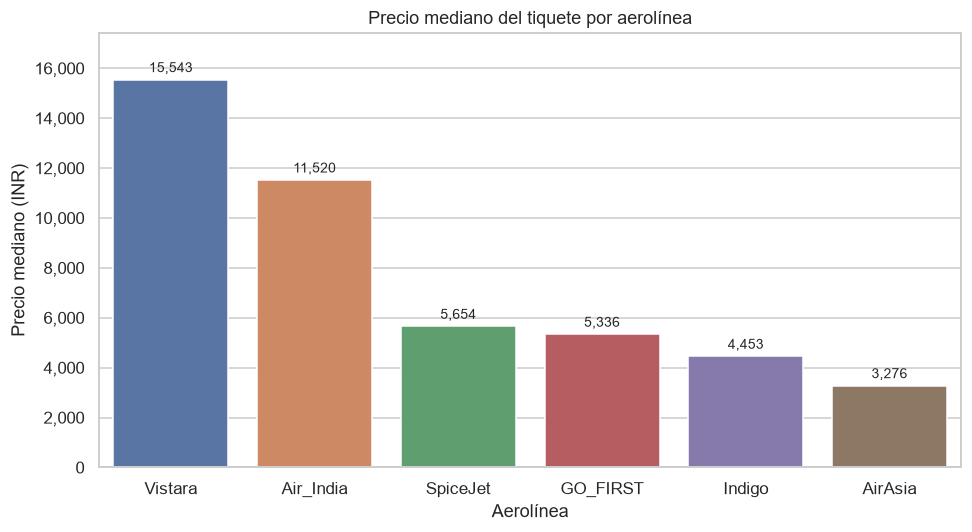

In [16]:
# Formateador de miles reutilizado en el resto del punto 8
miles = plt.FuncFormatter(lambda v, p: f"{v:,.0f}")

med_aero = (
    df.groupby("airline")["price"]
      .agg(mediana="median", media="mean", n="size")
      .sort_values("mediana", ascending=False)
      .reset_index()
)
display(med_aero)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=med_aero, x="airline", y="mediana",
    hue="airline", palette="deep", legend=False, ax=ax,
)
for cont in ax.containers:
    ax.bar_label(cont, fmt="{:,.0f}", padding=3, fontsize=9)

ax.set_title("Precio mediano del tiquete por aerolínea")
ax.set_xlabel("Aerolínea")
ax.set_ylabel("Precio mediano (INR)")
ax.yaxis.set_major_formatter(miles)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()


**Interpretación.** El ranking muestra una separación enorme y aparentemente inexplicable: Vistara (mediana 15.543 INR) y Air_India (11.520 INR) cobran entre 2 y 5 veces más que SpiceJet (5.654), GO_FIRST (5.336), Indigo (4.453) y AirAsia (3.276). La brecha entre la primera y la última aerolínea es de casi 12.300 INR, un factor de 4,7x. También conviene notar la distancia entre media y mediana en las dos primeras (Vistara: media 30.397 frente a mediana 15.543), señal inequívoca de que dentro de esas aerolíneas conviven dos poblaciones de precios y no una sola.

En términos del negocio de tarifas aéreas, este gráfico invita a la conclusión falsa de que "Vistara es una aerolínea cara". Antes de aceptarla hay que preguntarse si todas las aerolíneas están compitiendo en el mismo producto, es decir, si todas venden las mismas cabinas.

**Recomendación.** Como responsable de la toma de decisiones, se recomienda **no usar esta gráfica como insumo para ninguna decisión comercial ni de modelado hasta desagregar por `class`**. Un ranking de precios construido sobre un mix de producto no comparable es un artefacto estadístico (paradoja de Simpson en potencia), y una decisión de pricing o de benchmarking competitivo tomada sobre él llevaría a errores costosos. La verificación se hace en la gráfica siguiente.


### 8.2 — Barras agrupadas: precio mediano por aerolínea y clase

Se contrasta la hipótesis planteada arriba. Primero se verifica con una tabla de contingencia qué aerolíneas venden efectivamente cada cabina, y luego se grafica el precio mediano desagregado.


class,Business,Economy
airline,,
AirAsia,0,16098
Air_India,32898,47994
GO_FIRST,0,23173
Indigo,0,43120
SpiceJet,0,9011
Vistara,60589,67270



Aerolíneas que venden Business: ['Air_India', 'Vistara']


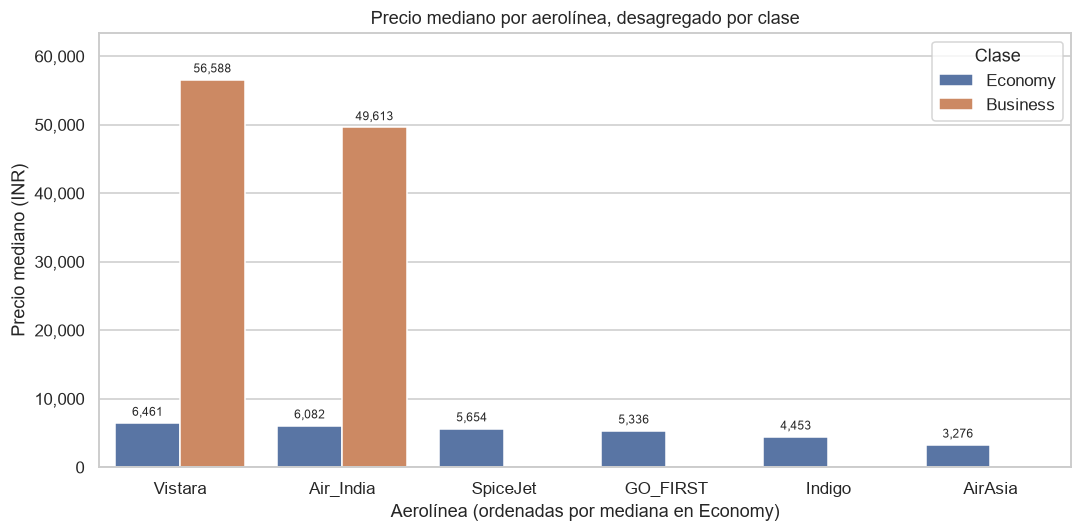

In [17]:
tab = pd.crosstab(df["airline"], df["class"])
display(tab)
print("\nAerolíneas que venden Business:", list(tab.index[tab["Business"] > 0]))

med_ac = (
    df.groupby(["airline", "class"])["price"].median().reset_index(name="mediana")
)
orden = (
    df[df["class"] == "Economy"].groupby("airline")["price"]
      .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=med_ac, x="airline", y="mediana", hue="class",
    order=orden, palette="deep", ax=ax,
)
for cont in ax.containers:
    ax.bar_label(cont, fmt="{:,.0f}", padding=3, fontsize=8)

ax.set_title("Precio mediano por aerolínea, desagregado por clase")
ax.set_xlabel("Aerolínea (ordenadas por mediana en Economy)")
ax.set_ylabel("Precio mediano (INR)")
ax.yaxis.set_major_formatter(miles)
ax.legend(title="Clase")
ax.margins(y=0.12)
plt.tight_layout()
plt.show()


**Interpretación.** La tabla de contingencia resuelve el enigma: **solo Vistara (60.589 registros) y Air_India (32.898) venden clase Business**; AirAsia, GO_FIRST, Indigo y SpiceJet operan exclusivamente en Economy y tienen cero registros en Business. El "sobreprecio" de la gráfica 8.1 no era una política tarifaria más agresiva, era simplemente un mix de producto distinto.

Al comparar dentro de la misma cabina, la historia cambia por completo. En Economy las medianas se aprietan en un rango estrecho: Vistara 6.461, Air_India 6.082, SpiceJet 5.654, GO_FIRST 5.336, Indigo 4.453 y AirAsia 3.276 INR. La brecha se reduce de 4,7x a apenas 2,0x, y ese diferencial residual sí es interpretable como posicionamiento real (aerolíneas de servicio completo frente a low-cost). En Business, Vistara (56.588) se ubica un 14% por encima de Air_India (49.613).

**Recomendación.** Como responsable de la toma de decisiones se recomienda **tratar `class` como la variable de segmentación primaria de todo el análisis y del modelo**. En concreto: (a) el modelo de regresión debe incluir `class` obligatoriamente, y conviene evaluar interacciones `class × airline` en lugar de efectos aditivos, porque el efecto de la aerolínea sobre el precio no es el mismo en las dos cabinas; (b) para el benchmarking competitivo del área comercial, todo reporte de precio por aerolínea debe publicarse desagregado por cabina, y se recomienda **prohibir el indicador de precio promedio por aerolínea sin segmentar**, ya que induce sistemáticamente a error.


### 8.3 — Barras: precio mediano por número de escalas y volumen por ciudad de origen

Dos vistas complementarias de barras: el efecto de `stops` sobre la tarifa y el reparto del volumen de registros entre las seis ciudades de origen.


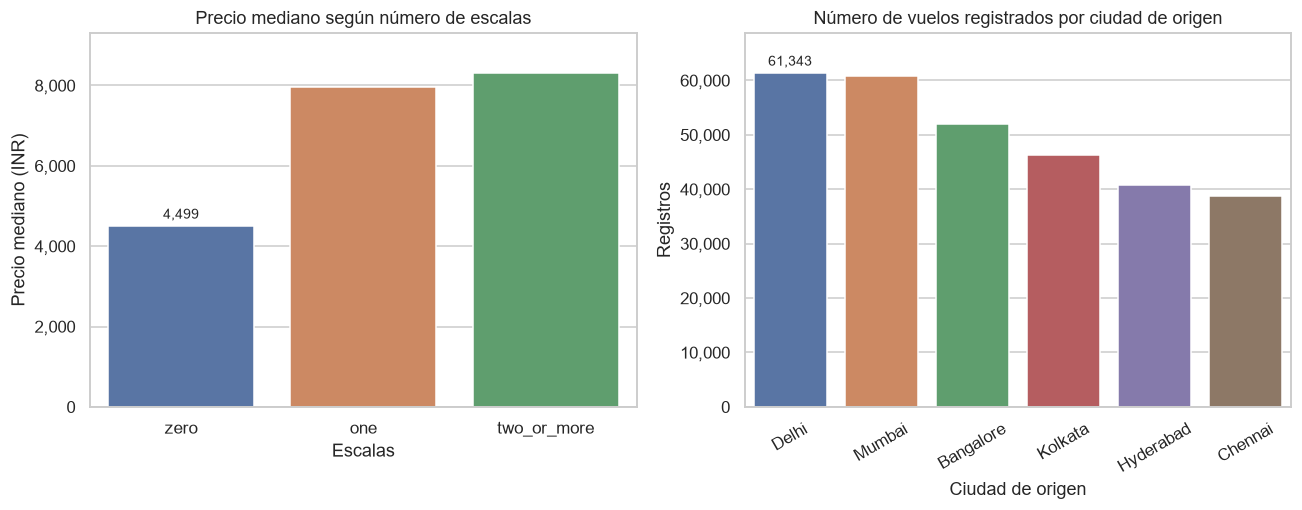

In [18]:
orden_stops = ["zero", "one", "two_or_more"]
med_stops = (
    df.groupby("stops")["price"].median().reindex(orden_stops).reset_index(name="mediana")
)
ciudades = df["source_city"].value_counts().reset_index()
ciudades.columns = ["source_city", "n"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.barplot(
    data=med_stops, x="stops", y="mediana",
    hue="stops", palette="deep", legend=False, ax=axes[0],
)
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3, fontsize=9)
axes[0].set_title("Precio mediano según número de escalas")
axes[0].set_xlabel("Escalas")
axes[0].set_ylabel("Precio mediano (INR)")
axes[0].yaxis.set_major_formatter(miles)
axes[0].margins(y=0.12)

sns.barplot(
    data=ciudades, x="source_city", y="n",
    hue="source_city", palette="deep", legend=False, ax=axes[1],
)
axes[1].bar_label(axes[1].containers[0], fmt="{:,.0f}", padding=3, fontsize=9)
axes[1].set_title("Número de vuelos registrados por ciudad de origen")
axes[1].set_xlabel("Ciudad de origen")
axes[1].set_ylabel("Registros")
axes[1].yaxis.set_major_formatter(miles)
axes[1].tick_params(axis="x", rotation=30)
axes[1].margins(y=0.12)

plt.tight_layout()
plt.show()


**Interpretación.** El panel izquierdo muestra un salto muy marcado al pasar de vuelo directo a vuelo con escala: la mediana sube de 4.499 INR (`zero`) a 7.959 INR (`one`), un incremento del 77%, y luego prácticamente se estanca en 8.307 INR para `two_or_more` (apenas 4% adicional). El efecto no es lineal en el número de escalas: la primera escala concentra casi todo el diferencial. Esto es contraintuitivo desde la óptica del pasajero (un vuelo con escala es peor producto y sin embargo cuesta más) y se explica porque las escalas están correlacionadas con rutas largas y con la presencia de aerolíneas de servicio completo, no porque la escala en sí agregue valor. Vale la pena recordar además el fuerte desbalance de la variable: `one` acumula 250.863 registros (83,6%) frente a 36.004 de `zero` y 13.286 de `two_or_more`.

El panel derecho confirma que el volumen está razonablemente repartido entre las seis ciudades, de Delhi (61.343) a Chennai (38.700), con una relación máximo/mínimo de solo 1,6x. No hay ciudades marginales que obliguen a agrupar categorías.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **codificar `stops` como variable ordinal (0, 1, 2) pero sin asumir que su efecto sobre el precio es lineal**: dado el estancamiento entre `one` y `two_or_more`, conviene probar también una codificación binaria "directo / con escala", que captura casi toda la señal con un solo grado de libertad. Adicionalmente, se recomienda **no interpretar el diferencial de escalas como una relación causal de pricing** en presentaciones al negocio: es una asociación confundida con la ruta y la aerolínea, y proponer "vender escalas más caro" a partir de este gráfico sería un error de lectura. Sobre `source_city` se recomienda usar one-hot encoding directo, sin agrupar categorías, dado el balance observado.


### 8.4 — Pie: composición por clase y participación por aerolínea

Dos gráficas circulares. La primera reparte el total de registros entre Economy y Business; la segunda (en formato de anillo o *donut*) muestra la participación de cada aerolínea sobre el total.


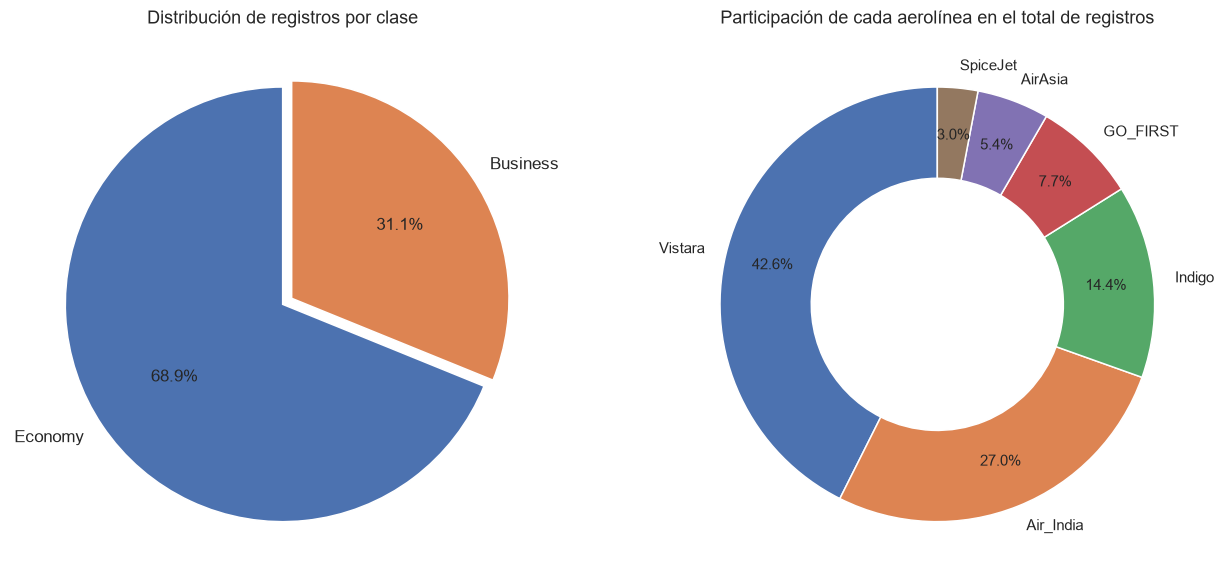

,registros,porcentaje
class,,
Economy,206666,68.85
Business,93487,31.15


In [19]:
conteo_clase = df["class"].value_counts()
conteo_aero = df["airline"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].pie(
    conteo_clase.values, labels=conteo_clase.index.tolist(),
    autopct="%1.1f%%", startangle=90, explode=(0, 0.05),
    colors=sns.color_palette("deep", len(conteo_clase)),
    textprops={"fontsize": 11},
)
axes[0].set_title("Distribución de registros por clase")

axes[1].pie(
    conteo_aero.values, labels=conteo_aero.index.tolist(),
    autopct="%1.1f%%", startangle=90, pctdistance=0.78,
    colors=sns.color_palette("deep", len(conteo_aero)),
    wedgeprops={"width": 0.42, "edgecolor": "white"},
    textprops={"fontsize": 10},
)
axes[1].set_title("Participación de cada aerolínea en el total de registros")

plt.tight_layout()
plt.show()

display(pd.concat([conteo_clase, (conteo_clase / len(df) * 100).round(2)], axis=1,
                  keys=["registros", "porcentaje"]))


**Interpretación.** El primer pie muestra que el dataset está compuesto por 68,9% de registros en Economy (206.666) y 31,1% en Business (93.487). No es un desbalance extremo, pero tampoco es una representación fiel del mercado real, donde la cabina Business suele ser una fracción mucho menor de los asientos vendidos: el dataset sobrerrepresenta Business, probablemente por la forma en que se recolectaron las cotizaciones. El segundo gráfico muestra una concentración fuerte del lado de la oferta: Vistara (42,6%) y Air_India (27,0%) suman casi el 70% de los registros, mientras SpiceJet apenas aporta el 3,0%.

Es importante señalar la **limitación propia del gráfico de torta**: solo es legible cuando hay pocas categorías y cuando estas son partes mutuamente excluyentes de un todo. El primer pie cumple ambas condiciones y comunica bien; el segundo ya está en el límite con seis sectores, y el ojo humano compara mal ángulos parecidos (AirAsia 5,4% frente a GO_FIRST 7,7%). Por eso se acompañó de la versión donut y de las barras del punto 8.1, que permiten comparación por longitud, mucho más precisa perceptualmente. Un pie con diez o más categorías, o usado para comparar magnitudes que no suman un total, sería directamente inadecuado.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **estratificar por `class` la partición train/test** (muestreo estratificado), para garantizar que ambas cabinas queden representadas en la misma proporción en los dos conjuntos y evitar que una partición aleatoria desbalanceada distorsione la evaluación del modelo. Adicionalmente, se recomienda **advertir explícitamente en el informe que la mezcla 69/31 no refleja el mix comercial real**, de modo que ningún indicador agregado sobre el total del dataset (precio promedio global, ingreso estimado) se presente como una cifra de mercado. Para los reportes recurrentes al negocio se recomienda preferir barras sobre pies cuando haya más de cuatro categorías.


### 8.5 — Histograma: distribución global del precio

Se examina la forma de la distribución de la variable objetivo sobre el total de los 300.153 registros, marcando la mediana y la media con líneas verticales.


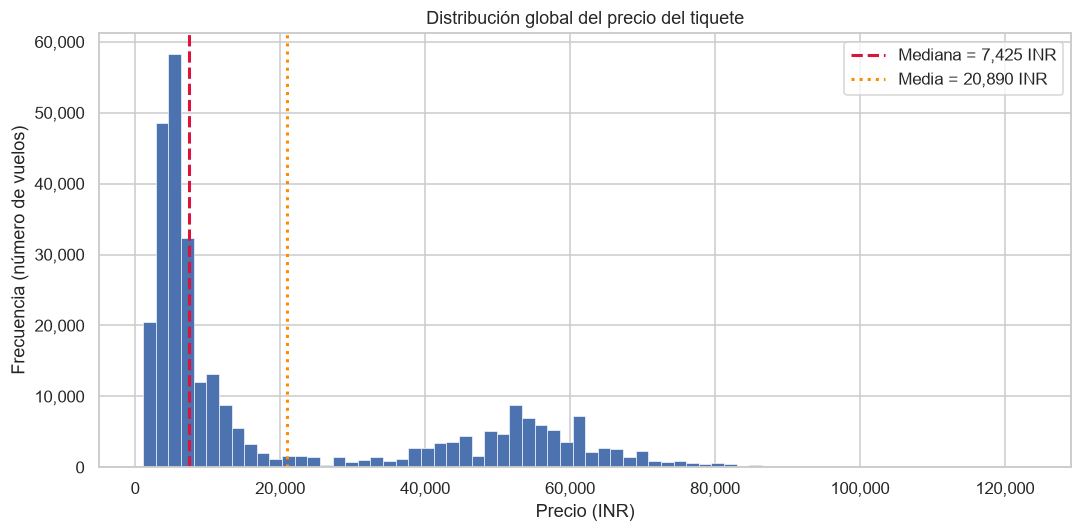

Asimetría (skew) de price: 1.061
Mediana 7,425 | Media 20,890 | Std 22,698


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["price"], bins=70, color=sns.color_palette("deep")[0], edgecolor="white", linewidth=0.4)
ax.axvline(df["price"].median(), color="crimson", linestyle="--", linewidth=2,
           label=f"Mediana = {df['price'].median():,.0f} INR")
ax.axvline(df["price"].mean(), color="darkorange", linestyle=":", linewidth=2,
           label=f"Media = {df['price'].mean():,.0f} INR")

ax.set_title("Distribución global del precio del tiquete")
ax.set_xlabel("Precio (INR)")
ax.set_ylabel("Frecuencia (número de vuelos)")
ax.xaxis.set_major_formatter(miles)
ax.yaxis.set_major_formatter(miles)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Asimetría (skew) de price: {df['price'].skew():.3f}")
print(f"Mediana {df['price'].median():,.0f} | Media {df['price'].mean():,.0f} | "
      f"Std {df['price'].std():,.0f}")


**Interpretación.** El histograma revela el hallazgo central del EDA: **la distribución del precio no es unimodal, es bimodal**. Se observa una primera moda muy alta y concentrada por debajo de los 15.000 INR, un valle casi vacío entre aproximadamente 15.000 y 25.000, y una segunda joroba mucho más ancha y aplanada entre 30.000 y 80.000 INR. La distancia entre la mediana (7.425 INR) y la media (20.890 INR) —un factor de 2,8x— y la asimetría positiva (skew = 1,061) son consecuencias directas de esa segunda moda.

Para el negocio esto significa que **no existe un "precio típico del tiquete" en este dataset**: hay dos mercados de tarifas superpuestos. Cualquier estadístico central calculado sobre el total (la media de 20.890 INR, en particular) describe un valor que casi ningún pasajero paga realmente, porque cae justo en el valle entre las dos poblaciones. Es el mismo fenómeno que distorsionaba el ranking de aerolíneas del punto 8.1.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **descartar la media global como métrica de reporte y sustituirla por la mediana desagregada por cabina**. Para el modelado, la bimodalidad advierte que un modelo lineal simple sobre el total tendrá dificultades para ajustar ambas modas: se recomienda incluir `class` como predictor de primer orden y, si el desempeño lo justifica, **evaluar modelos basados en árboles** (que particionan naturalmente el espacio y manejan bien estas mezclas) o bien **entrenar y evaluar dos modelos separados, uno por cabina**, comparando ambas estrategias con la misma métrica antes de decidir.


### 8.6 — Histogramas del precio separados por clase

Se repite el histograma anterior, pero separando las dos poblaciones. Esta es la lectura correcta de la variable objetivo.


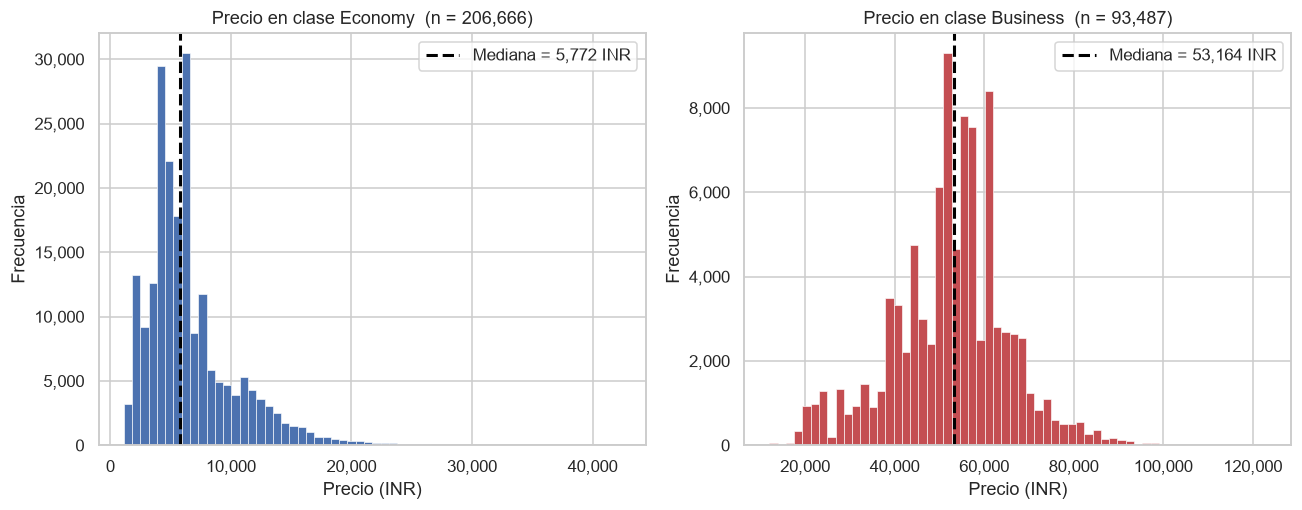

,count,mean,median,std,min,max
class,,,,,,
Business,93487,52540.1,53164.0,12969.3,12000,123071
Economy,206666,6572.3,5772.0,3743.5,1105,42349


In [21]:
eco = df[df["class"] == "Economy"]
bus = df[df["class"] == "Business"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, sub, nombre, color in [
    (axes[0], eco, "Economy", sns.color_palette("deep")[0]),
    (axes[1], bus, "Business", sns.color_palette("deep")[3]),
]:
    ax.hist(sub["price"], bins=60, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(sub["price"].median(), color="black", linestyle="--", linewidth=2,
               label=f"Mediana = {sub['price'].median():,.0f} INR")
    ax.set_title(f"Precio en clase {nombre}  (n = {len(sub):,})")
    ax.set_xlabel("Precio (INR)")
    ax.set_ylabel("Frecuencia")
    ax.xaxis.set_major_formatter(miles)
    ax.yaxis.set_major_formatter(miles)
    ax.legend()

plt.tight_layout()
plt.show()

display(df.groupby("class")["price"].agg(["count", "mean", "median", "std", "min", "max"]).round(1))


In [22]:
# Asimetría del precio: global y dentro de cada clase (sustenta la lectura de los histogramas)
asimetria_precio = pd.Series({
    "Global": df["price"].skew(),
    "Economy": eco["price"].skew(),
    "Business": bus["price"].skew(),
}, name="asimetría")
display(asimetria_precio.to_frame().round(3))


,asimetría
Global,1.061
Economy,1.703
Business,-0.095


**Interpretación.** Separadas, las dos poblaciones se comportan de manera mucho más ordenada. **Economy** (n = 206.666) se concentra entre 1.105 y 42.349 INR, con media 6.572 y mediana 5.772 muy próximas entre sí y una desviación estándar de 3.744: es una distribución **fuertemente asimétrica hacia la derecha** —su coeficiente de asimetría, 1,703, es incluso mayor que el 1,061 del conjunto completo que ya se calificó así en el Punto 3—, con la masa de los datos por debajo de los 10.000 INR y una cola derecha larga de tarifas de última hora. **Business** (n = 93.487) ocupa un rango completamente distinto, de 12.000 a 123.071 INR, con media 52.540 y mediana 53.164 prácticamente idénticas, lo que indica una distribución bastante simétrica, y una dispersión absoluta mucho mayor (std 12.969).

Un dato clave para el negocio: la zona en que los rangos se cruzan no es estrecha —va de 12.000 INR (mínimo de Business) a 42.349 INR (máximo de Economy), 30.349 INR de amplitud, y dentro de ella caen 19.708 registros de Economy y 17.555 de Business, cerca del 12,4 % del conjunto—, pero la masa de cada cabina sí está bien separada: un corte en 20.000 INR deja por debajo al 99,1 % de Economy y por encima al 99,5 % de Business, de modo que el precio por sí solo casi identifica la cabina. La cabina Business cuesta, en la mediana, **9,2 veces** lo que cuesta Economy.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **reportar todos los indicadores de precio segmentados por cabina, sin excepción**, y adoptar la mediana de Economy (5.772 INR) como referencia operativa del "precio del tiquete" en comunicaciones al negocio. Para el modelado, dado que la varianza del error crece con el nivel de precio (heterocedasticidad evidente entre los dos paneles), se recomienda **evaluar una transformación logarítmica de la variable objetivo** (`log(price)`) y compararla contra el modelo en escala original mediante RMSE y MAE sobre la escala original, para no elegir la transformación por comodidad estadística sino por desempeño medido.


### 8.7 — Histograma: distribución de la duración del vuelo

Se analiza la forma de `duration`, la otra variable continua predictora, medida en horas.


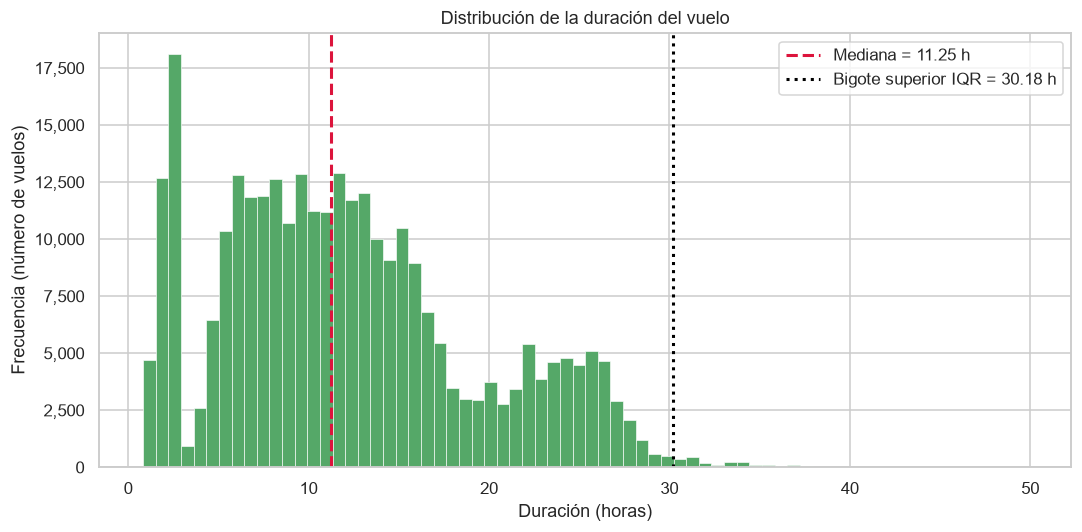

Q1 = 6.83 h | Q3 = 16.17 h | IQR = 9.34 h | máximo = 49.83 h
Vuelos por encima del bigote superior: 2,110 (0.70% del total)


In [23]:
d = df["duration"]
q1, q3 = d.quantile([0.25, 0.75])
iqr = q3 - q1
bigote = q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(d, bins=70, color=sns.color_palette("deep")[2], edgecolor="white", linewidth=0.4)
ax.axvline(d.median(), color="crimson", linestyle="--", linewidth=2,
           label=f"Mediana = {d.median():.2f} h")
ax.axvline(bigote, color="black", linestyle=":", linewidth=2,
           label=f"Bigote superior IQR = {bigote:.2f} h")

ax.set_title("Distribución de la duración del vuelo")
ax.set_xlabel("Duración (horas)")
ax.set_ylabel("Frecuencia (número de vuelos)")
ax.yaxis.set_major_formatter(miles)
ax.legend()
plt.tight_layout()
plt.show()

n_out = int((d > bigote).sum())
print(f"Q1 = {q1:.2f} h | Q3 = {q3:.2f} h | IQR = {iqr:.2f} h | máximo = {d.max():.2f} h")
print(f"Vuelos por encima del bigote superior: {n_out:,} ({n_out / len(d) * 100:.2f}% del total)")


**Interpretación.** La duración presenta una distribución claramente asimétrica hacia la derecha, con un pico pronunciado en el tramo corto (los vuelos directos, de aproximadamente 2 horas) seguido de una meseta amplia entre 5 y 20 horas y una cola que se extiende hasta las 49,83 horas. La mediana está en 11,25 horas, el rango intercuartílico va de 6,83 a 16,17 horas y el bigote superior del criterio IQR se ubica en 30,18 horas. Por encima de ese umbral quedan 2.110 vuelos, apenas el **0,70% del total**.

Desde el negocio, esos itinerarios de más de 30 horas no son errores de captura: son conexiones largas con esperas prolongadas en el aeropuerto de tránsito, un producto real que efectivamente se vende en el mercado indio doméstico. La bimodalidad suave de la distribución (pico corto separado de la meseta) es el reflejo directo de la variable `stops`, como se verificará en el boxplot 8.11.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **conservar los 2.110 registros de larga duración**, en línea con la decisión ya tomada y documentada en el punto 7: son observaciones válidas del fenómeno, no ruido, y eliminarlas sesgaría el modelo justo en el segmento de itinerarios más complejos. Se recomienda además **verificar el desempeño del modelo final por separado en ese 0,70% de la cola**, para confirmar que no se degrada de forma inaceptable, y considerar la duración en escala logarítmica o discretizada por tramos si se observa que la relación con el precio no es lineal.


### 8.8 — Scatter plot: días de anticipación frente a precio

Se examina la relación entre `days_left` y `price`, coloreando por clase. Por legibilidad se dibuja una muestra aleatoria de 20.000 puntos con transparencia baja: graficar los 300.153 registros produciría una mancha sólida ilegible y una figura innecesariamente pesada. **Las estadísticas y correlaciones reportadas se calculan siempre sobre el total de los datos**, no sobre la muestra.


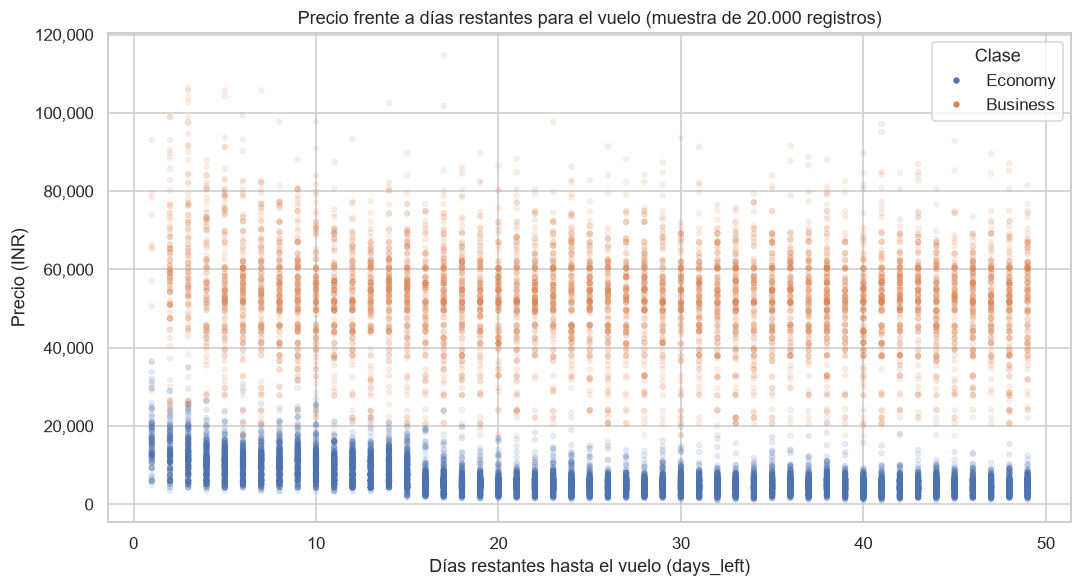

Correlaciones de Pearson calculadas sobre los 300.153 registros:
  price ~ days_left  (global)   : -0.0919
  price ~ days_left  (Economy)  : -0.5596
  price ~ days_left  (Business) : -0.0913


In [24]:
muestra = df.sample(n=20000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.scatterplot(
    data=muestra, x="days_left", y="price", hue="class",
    alpha=0.15, s=14, edgecolor=None, palette="deep", ax=ax,
)
leg = ax.legend(title="Clase")
for h in leg.legend_handles:
    h.set_alpha(1.0)

ax.set_title("Precio frente a días restantes para el vuelo (muestra de 20.000 registros)")
ax.set_xlabel("Días restantes hasta el vuelo (days_left)")
ax.set_ylabel("Precio (INR)")
ax.yaxis.set_major_formatter(miles)
plt.tight_layout()
plt.show()

print("Correlaciones de Pearson calculadas sobre los 300.153 registros:")
print(f"  price ~ days_left  (global)   : {df['price'].corr(df['days_left']):.4f}")
print(f"  price ~ days_left  (Economy)  : {eco['price'].corr(eco['days_left']):.4f}")
print(f"  price ~ days_left  (Business) : {bus['price'].corr(bus['days_left']):.4f}")


**Interpretación.** La nube confirma visualmente lo que ya mostraban los histogramas: los puntos se organizan en dos bandas horizontales netamente separadas, la de Economy por debajo de ~20.000 INR y la de Business por encima de ~35.000 INR, con un corredor vacío entre ambas. Dentro de cada banda se aprecia un engrosamiento hacia arriba en el extremo izquierdo (pocos días restantes) que se disipa rápidamente a partir de los 20 días.

Aquí se explica un resultado que a primera vista parecía descartar la variable: la correlación de Pearson global entre `price` y `days_left` es de apenas **-0,092**, un valor que sugeriría que la anticipación no importa. Sin embargo, al calcularla **solo dentro de Economy sube a -0,560**, una relación fuerte. La correlación global era baja por dos razones acumuladas: (a) la varianza entre cabinas domina por completo la varianza dentro de cada cabina, diluyendo cualquier señal, y (b) la relación no es lineal, de modo que el coeficiente de Pearson —que solo mide asociación lineal— la subestima incluso dentro de un mismo segmento (en Business queda en -0,091).

**Recomendación.** Como responsable de la toma de decisiones se recomienda **conservar `days_left` como predictor y rechazar explícitamente cualquier selección de variables basada únicamente en la correlación lineal marginal contra el total**: ese criterio habría eliminado una de las variables más informativas del dataset. Se recomienda formalizar esta regla en el pipeline de selección de características, evaluando siempre la asociación dentro de los segmentos relevantes y con medidas no lineales (por ejemplo correlación de Spearman o información mutua) además de Pearson.


### 8.9 — Precio mediano por día de anticipación (solo Economy)

Para aislar el patrón temporal se agrega el precio mediano por cada uno de los 49 valores de `days_left`, restringiendo el análisis a la clase Economy, donde la señal es nítida.


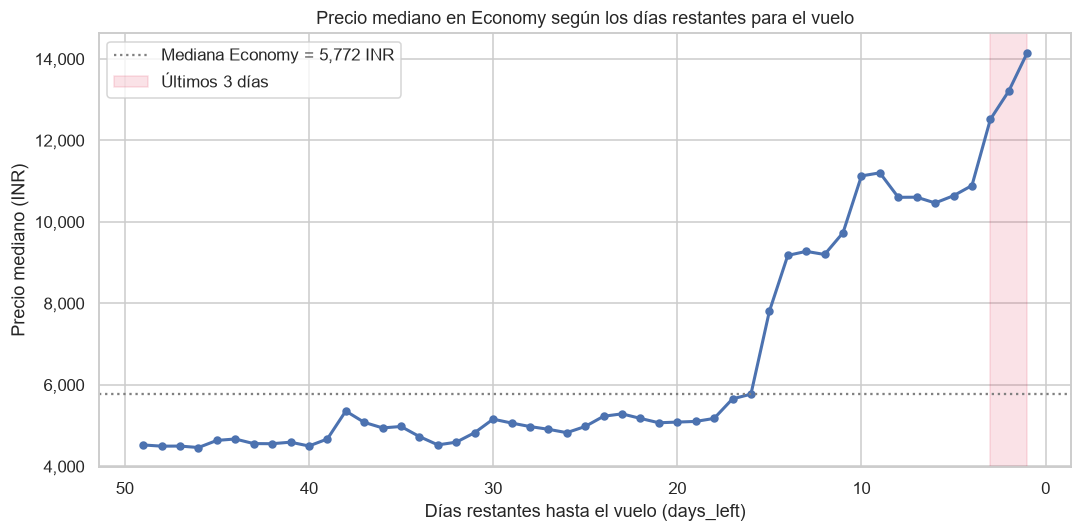

,days_left,mediana
0,1,14150.0
1,2,13212.0
2,3,12518.0
3,4,10893.0
4,5,10643.0
5,6,10465.5


Meseta (días 20 a 49): mínimo 4,462 INR | máximo 5,358 INR


In [25]:
eco_dl = eco.groupby("days_left")["price"].median().reset_index(name="mediana")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eco_dl["days_left"], eco_dl["mediana"], marker="o", markersize=4.5,
        linewidth=2, color=sns.color_palette("deep")[0])
ax.axhline(eco["price"].median(), color="gray", linestyle=":", linewidth=1.5,
           label=f"Mediana Economy = {eco['price'].median():,.0f} INR")
ax.axvspan(1, 3, color="crimson", alpha=0.12, label="Últimos 3 días")

ax.set_title("Precio mediano en Economy según los días restantes para el vuelo")
ax.set_xlabel("Días restantes hasta el vuelo (days_left)")
ax.set_ylabel("Precio mediano (INR)")
ax.yaxis.set_major_formatter(miles)
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

display(eco_dl.head(6))
print(f"Meseta (días 20 a 49): mínimo {eco_dl.query('days_left >= 20')['mediana'].min():,.0f} INR "
      f"| máximo {eco_dl.query('days_left >= 20')['mediana'].max():,.0f} INR")


**Interpretación.** Agregada y aislada, la relación se vuelve inequívoca. La curva (leída de derecha a izquierda, es decir, a medida que se acerca la fecha del vuelo) es esencialmente **plana durante casi toda la ventana de venta**: entre los días 49 y 20 la mediana oscila apenas entre 4.462,5 y 5.358 INR, una banda de menos de 900 INR de amplitud. A partir de aproximadamente 20 días comienza un ascenso gradual que se convierte en un **repunte abrupto en la última semana**, culminando en 12.518 INR a 3 días del vuelo, 13.212 a 2 días y **14.150 INR el día anterior**. Comprar el día previo cuesta **2,8 veces** lo que cuesta comprar con veinte días de anticipación (14.150 frente a 5.087 INR), y **3,2 veces** el mínimo de la meseta (4.462,5 INR, alcanzado en el día 46).

Esta es la firma clásica del *revenue management* aéreo: las aerolíneas reservan inventario para el pasajero corporativo de última hora, cuya demanda es inelástica al precio, y solo lo liberan a tarifa alta cuando la ventana se cierra. El comportamiento es marcadamente no lineal y prácticamente todo el efecto se concentra en los últimos 10 días.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **no introducir `days_left` en el modelo como término lineal simple**, porque un coeficiente único promediaría la meseta plana con el salto final y subestimaría gravemente las tarifas de última hora, justo el segmento de mayor valor. En su lugar se recomienda **transformar la variable** (logaritmo o inverso de los días restantes) o **discretizarla en tramos de negocio** —por ejemplo 1-3, 4-7, 8-14, 15-30 y más de 30 días— que además resultan directamente accionables para el área comercial. Del lado del negocio, se recomienda comunicar al pasajero que la ventana óptima de compra se cierra alrededor de los 20 días.


### 8.10 — Boxplot: precio por clase y por aerolínea

Los diagramas de caja resumen mediana, cuartiles y valores fuera de bigote. Se presentan dos paneles: el precio por cabina y el precio por aerolínea desagregado también por cabina.


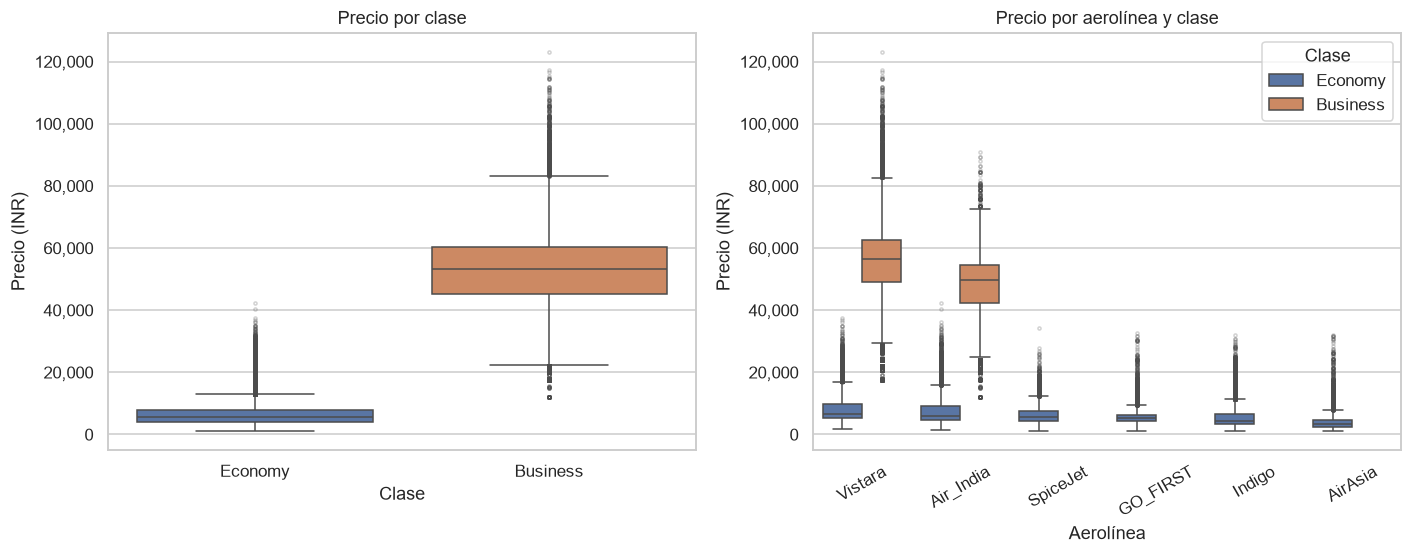

Economy  : bigotes [-1,186 ; 13,106] INR | fuera de bigote: 13,749 (6.65%)
Business : bigotes [22,368 ; 83,212] INR | fuera de bigote: 3,650 (3.90%)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.boxplot(
    data=df, x="class", y="price", hue="class",
    palette="deep", legend=False, ax=axes[0], flierprops={"markersize": 2, "alpha": 0.25},
)
axes[0].set_title("Precio por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Precio (INR)")
axes[0].yaxis.set_major_formatter(miles)

sns.boxplot(
    data=df, x="airline", y="price", hue="class", order=orden,
    palette="deep", ax=axes[1], flierprops={"markersize": 2, "alpha": 0.25},
)
axes[1].set_title("Precio por aerolínea y clase")
axes[1].set_xlabel("Aerolínea")
axes[1].set_ylabel("Precio (INR)")
axes[1].yaxis.set_major_formatter(miles)
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Clase", loc="upper right")

plt.tight_layout()
plt.show()

for nombre, sub in [("Economy", eco), ("Business", bus)]:
    p = sub["price"]
    q1, q3 = p.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((p < lo) | (p > hi)).sum())
    print(f"{nombre:9s}: bigotes [{lo:,.0f} ; {hi:,.0f}] INR | "
          f"fuera de bigote: {n:,} ({n / len(p) * 100:.2f}%)")


**Interpretación.** El panel izquierdo muestra dos cajas que casi no se solapan: la de Economy es estrecha y está aplastada contra la base del eje, con bigotes que llegan hasta 13.106 INR y **13.749 puntos por fuera (6,65% de la cabina)**; la de Business es mucho más alta y ancha, con bigotes entre 22.368 y 83.212 INR y 3.650 valores fuera de rango. La comparación visual deja claro que la escala de precios de una cabina no sirve para juzgar la otra.

El panel derecho refina la lectura del punto 8.2: dentro de Economy las cajas de las seis aerolíneas están a alturas similares y con solapamiento amplio, y las columnas de Business solo existen para Vistara y Air_India. Cada caja de Economy arrastra su propia nube de puntos altos, que corresponden a las compras de última hora identificadas en 8.9.

Lo relevante es la naturaleza de esos valores fuera de bigote: **no son errores, son tarifas de última hora legítimas y perfectamente explicables por `days_left`**. Un criterio automático de limpieza por IQR habría eliminado más de 17.000 registros que contienen precisamente la señal de mayor valor comercial del dataset.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **ratificar la decisión adoptada en el punto 7: documentar los valores atípicos pero no eliminarlos**, ya que son observaciones válidas del fenómeno de negocio y su exclusión sesgaría el modelo contra el segmento de mayor tarifa. Se recomienda además **calcular los umbrales de detección de anomalías siempre dentro de cada cabina y no sobre el total**, y usar métricas de evaluación robustas (MAE junto a RMSE) para que la cola de tarifas altas no domine por completo la evaluación y la comparación entre modelos. La pérdida que se optimiza durante el entrenamiento es otra decisión —en varios de estos modelos ya es por defecto el error cuadrático—, y por eso mismo el MAE aporta una lectura complementaria al reportar los resultados.


### 8.11 — Boxplot: duración del vuelo por número de escalas

Se verifica la hipótesis planteada en 8.7 sobre el origen de la forma bimodal de la duración.


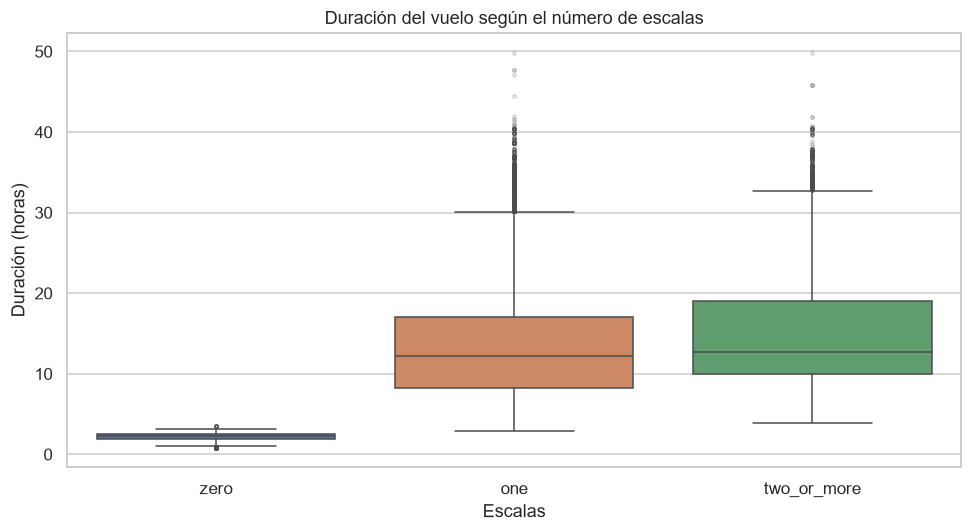

,n,mediana,q1,q3,máximo
stops,,,,,
zero,36004,2.25,1.92,2.58,3.58
one,250863,12.25,8.25,17.00,49.83
two_or_more,13286,12.67,10.00,19.08,49.83


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x="stops", y="duration", hue="stops", order=orden_stops,
    palette="deep", legend=False, ax=ax, flierprops={"markersize": 2, "alpha": 0.25},
)
ax.set_title("Duración del vuelo según el número de escalas")
ax.set_xlabel("Escalas")
ax.set_ylabel("Duración (horas)")
plt.tight_layout()
plt.show()

display(
    df.groupby("stops")["duration"]
      .agg(n="size", mediana="median",
           q1=lambda s: s.quantile(0.25),
           q3=lambda s: s.quantile(0.75),
           máximo="max")
      .reindex(orden_stops).round(2)
)


**Interpretación.** La gráfica confirma la hipótesis: la caja de los vuelos directos (`zero`) es extremadamente compacta y está centrada en una mediana de **2,25 horas**, mientras que `one` y `two_or_more` se sitúan en medianas de **12,25 y 12,67 horas** respectivamente, con cajas mucho más altas. La brecha entre vuelo directo y vuelo con una escala es de exactamente 10,00 horas; entre una y dos escalas es de apenas 0,42 horas. El pico corto que se veía en el histograma 8.7 es, entonces, íntegramente el grupo de vuelos directos, y `stops` explica buena parte de la forma de `duration`.

Este resultado tiene una consecuencia directa para el modelado: `stops` y `duration` **codifican información fuertemente redundante**. Y explica también el hallazgo del punto 8.3: las escalas no son caras por ser escalas, sino porque acompañan itinerarios largos operados mayoritariamente por aerolíneas de servicio completo, que además son las únicas que ofrecen Business.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **revisar la colinealidad entre `stops` y `duration` antes de entrenar** —calculando el VIF o la correlación entre la duración y la codificación ordinal de las escalas— y, si resulta alta, conservar `duration` (que es continua y más informativa) tratando `stops` como variable de apoyo o eliminándola de los modelos lineales. En modelos basados en árboles la redundancia no invalida las predicciones, pero sí distorsiona las medidas de importancia de variables, por lo que se recomienda **no interpretar la importancia de `stops` y `duration` de forma independiente** en los informes al negocio.


### 8.12 — Mapa de calor de correlaciones entre las variables numéricas

Cierre del EDA: matriz de correlación de Pearson entre las tres variables numéricas, calculada sobre el total y sobre la clase Economy, para dejar documentado el efecto de la segmentación.


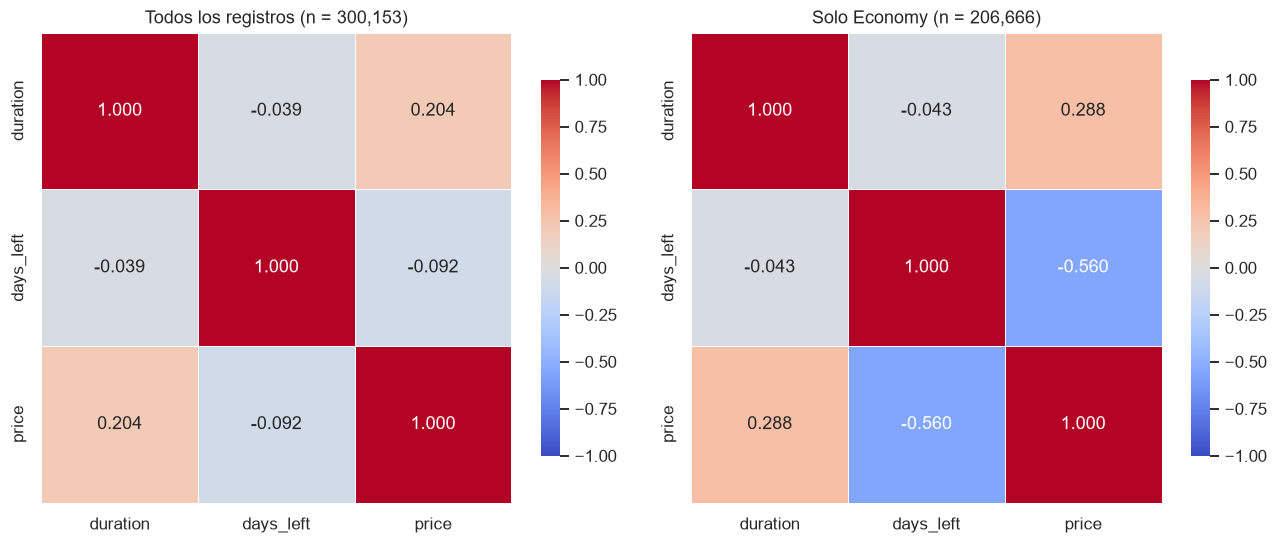

In [28]:
num = ["duration", "days_left", "price"]
corr_total = df[num].corr()
corr_eco = eco[num].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, mat, titulo in [
    (axes[0], corr_total, f"Todos los registros (n = {len(df):,})"),
    (axes[1], corr_eco, f"Solo Economy (n = {len(eco):,})"),
]:
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title(titulo)

plt.tight_layout()
plt.show()


**Interpretación.** Los dos mapas cuentan historias distintas con los mismos datos. Sobre el total, todas las correlaciones son débiles: `price` con `duration` alcanza 0,204 y `price` con `days_left` apenas -0,092, mientras entre `duration` y `days_left` no hay prácticamente relación lineal (-0,039). Conviene no leer eso como independencia: una correlación de Pearson cercana a cero solo descarta la asociación **lineal**, no cualquier otra forma de relación; lo que sí es razonable es que no haya relación causal entre ambas (la anticipación de compra no determina la duración del itinerario). Leído aisladamente, este panel sugeriría que ninguna de las variables numéricas sirve para predecir el precio.

El panel derecho desmiente esa lectura: restringido a Economy, `price` con `days_left` pasa de -0,092 a **-0,560**, y `price` con `duration` sube de 0,204 a 0,288. La conclusión metodológica del punto 8.8 queda así confirmada de forma cuantitativa: la varianza introducida por la mezcla de cabinas enmascaraba por completo las relaciones existentes dentro de cada segmento.

**Recomendación.** Como responsable de la toma de decisiones se recomienda **incluir las tres variables numéricas en el modelo** y descartar formalmente la idea de filtrar predictores por correlación marginal contra el objetivo global. Se recomienda además **dejar constancia en el informe de que toda métrica de asociación debe reportarse segmentada por `class`**, porque este dataset demuestra que el agregado puede invertir o anular conclusiones válidas dentro de los segmentos. La baja correlación entre `duration` y `days_left` es, en cambio, una buena noticia: aportan información complementaria y no compiten entre sí en el modelo.


### Síntesis del Punto 8

El EDA deja cinco decisiones tomadas y documentadas, que alimentan directamente las fases siguientes:

1. **`class` es la variable estructurante del dataset.** Toda métrica, gráfica y validación debe segmentarse por cabina; los agregados globales son engañosos (puntos 8.1, 8.2, 8.5, 8.12).
2. **La variable objetivo es bimodal y heterocedástica.** Se evaluará la transformación logarítmica de `price` y se compararán modelos lineales frente a modelos basados en árboles (punto 8.6).
3. **`days_left` es informativa pero no lineal.** Se transformará o discretizará en tramos, y no se descartará por su baja correlación marginal (puntos 8.8, 8.9).
4. **Los valores atípicos se conservan.** Son tarifas de última hora legítimas, no errores de captura; se ratifica la decisión del punto 7 (puntos 8.7, 8.10).
5. **`stops` y `duration` son redundantes entre sí.** Se verificará la colinealidad antes de entrenar y se tendrá precaución al interpretar sus importancias relativas (punto 8.11).


## Punto 9 — Codificación de las variables categóricas

### Por qué esta decisión no se puede tomar "por defecto"

Es tentador resolver la codificación con una sola línea —aplicar One-Hot a todo lo que sea texto y seguir adelante— pero esa comodidad tiene un costo. La técnica adecuada no depende del tipo de dato, sino de **tres condiciones que hay que evaluar simultáneamente en cada variable**:

1. **¿Existe un orden natural entre las categorías?** No basta con que las categorías se puedan ordenar de alguna manera arbitraria; se necesita que el orden sea intrínseco al fenómeno, de modo que decir "esta categoría está antes que aquella" signifique algo en el dominio del problema.
2. **¿Cuántas categorías distintas hay?** La cardinalidad determina cuántas columnas nuevas produce una expansión One-Hot y, con ello, cuánto crece la dimensionalidad y qué tan dispersa queda la matriz de entrada.
3. **¿Qué algoritmos van a consumir esas columnas?** Un mismo esquema de codificación puede ser inocuo para un modelo y destructivo para otro.

### El problema de fondo: la distancia falsa

Codificar de forma ordinal una variable que no tiene orden consiste en asignar enteros consecutivos a categorías que no guardan ninguna relación de precedencia. Si a `source_city` le asignáramos Bangalore = 0, Chennai = 1, Delhi = 2, Hyderabad = 3, Kolkata = 4 y Mumbai = 5, estaríamos afirmando implícitamente tres cosas falsas: que Chennai (1) está "más cerca" de Delhi (2) que de Mumbai (5); que la distancia entre Bangalore y Chennai es la misma que entre Kolkata y Mumbai; y que existe una progresión Bangalore → Mumbai que tiene sentido recorrer. Ninguna de las tres se sostiene: las etiquetas provienen simplemente del orden alfabético.

Lo interesante es que esa distorsión **no afecta a todos los modelos por igual**:

- **Los árboles (Decision Tree, Random Forest, Gradient Boosting) son en buena medida tolerantes.** Un árbol no interpreta la magnitud del número; solo hace cortes de la forma `variable <= umbral`. Con suficientes divisiones sucesivas puede aislar cualquier subconjunto de categorías, así que el orden arbitrario le cuesta profundidad, no corrección. El precio que paga es indirecto: necesita más nodos para recuperar una partición que One-Hot le habría dado en un solo corte.
- **La Regresión Lineal Múltiple queda directamente corrompida.** Al estimar un único coeficiente $\beta$ para esa columna, el modelo impone que el efecto sobre el precio sea *monotónico y de paso constante*: pasar de Bangalore a Chennai tendría el mismo efecto sobre la tarifa que pasar de Kolkata a Mumbai. Eso no es una aproximación imperfecta, es una restricción estructural equivocada.
- **KNN queda corrompido de otra forma.** Su predicción depende por completo de la métrica de distancia, y con una codificación ordinal falsa la distancia entre dos vuelos hereda esa geometría inventada: dos registros idénticos salvo por la ciudad de origen quedarían a distancia 1 o a distancia 5 según qué par de ciudades sean, sin ninguna razón sustantiva.

Aquí está el criterio que gobierna todo el punto: **en la Fase 3 los cinco modelos —Regresión Lineal Múltiple, KNN Regressor, Decision Tree, Random Forest y Gradient Boosting— comparten un único pipeline de preprocesamiento**. Por lo tanto la codificación debe elegirse pensando en el modelo *más exigente*, no en el más tolerante. Un esquema que solo funcione bien para los árboles sesgaría la comparación en contra de la regresión y de KNN, y la conclusión de la Fase 5 sobre cuál modelo es mejor dejaría de ser válida.

Antes de decidir, revisemos la evidencia: la cardinalidad y las categorías de cada variable categórica, y las medianas de precio por franja de salida dentro de Economy.


In [29]:
COLS_CAT = ["airline", "flight", "source_city", "departure_time",
            "stops", "arrival_time", "destination_city", "class"]

filas = []
for c in COLS_CAT:
    cats = sorted(df[c].unique().tolist())
    n = len(cats)
    muestra = ", ".join(cats) if n <= 8 else ", ".join(cats[:4]) + f", ... (+{n - 4} más)"
    filas.append({"variable": c, "cardinalidad": n, "categorias": muestra})

resumen_cat = pd.DataFrame(filas).sort_values("cardinalidad").set_index("variable")
display(resumen_cat)

print(f"\nColumnas que generaría un One-Hot sobre TODAS las categóricas: "
      f"{sum(df[c].nunique() for c in COLS_CAT)}")
print(f"De ellas, aportadas solo por 'flight': {df['flight'].nunique()}")
print(f"Cada código de vuelo pertenece a un máximo de "
      f"{df.groupby('flight')['airline'].nunique().max()} aerolínea(s)")


,cardinalidad,categorias
variable,,
class,2,"Business, Economy"
stops,3,"one, two_or_more, zero"
airline,6,"AirAsia, Air_India, GO_FIRST, Indigo, SpiceJet..."
source_city,6,"Bangalore, Chennai, Delhi, Hyderabad, Kolkata,..."
arrival_time,6,"Afternoon, Early_Morning, Evening, Late_Night,..."
departure_time,6,"Afternoon, Early_Morning, Evening, Late_Night,..."
destination_city,6,"Bangalore, Chennai, Delhi, Hyderabad, Kolkata,..."
flight,1561,"6E-102, 6E-105, 6E-113, 6E-121, ... (+1557 más)"



Columnas que generaría un One-Hot sobre TODAS las categóricas: 1596
De ellas, aportadas solo por 'flight': 1561
Cada código de vuelo pertenece a un máximo de 1 aerolínea(s)


In [30]:
# Mediana de price por franja de salida dentro de Economy:
# evidencia para decidir la codificación de departure_time
orden_franjas = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
med_franja = (
    eco.groupby("departure_time")["price"]
       .median()
       .reindex(orden_franjas)
)
display(med_franja.to_frame("mediana de price en Economy (INR)"))

print("Recorrido cronológico de la mediana (INR):",
      " -> ".join(f"{v:,.0f}" for v in med_franja))
print(f"Franja más barata: {med_franja.idxmin()} ({med_franja.min():,.0f}) | "
      f"más cara: {med_franja.idxmax()} ({med_franja.max():,.0f})")


,mediana de price en Economy (INR)
departure_time,
Early_Morning,5778.0
Morning,6067.0
Afternoon,5656.0
Evening,5507.0
Night,5525.0
Late_Night,4439.0


Recorrido cronológico de la mediana (INR): 5,778 -> 6,067 -> 5,656 -> 5,507 -> 5,525 -> 4,439
Franja más barata: Late_Night (4,439) | más cara: Morning (6,067)


La tabla de cardinalidades deja el panorama claro: siete de las ocho variables tienen cardinalidad baja (entre 2 y 6 categorías) y una sola, `flight`, se dispara a **1.561 valores distintos**. Esa asimetría marca la estructura de la decisión: las siete primeras se resuelven eligiendo entre One-Hot y Ordinal, mientras que `flight` plantea un problema cualitativamente distinto.

### Tabla de decisión

| Variable | Cardinalidad | ¿Orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| `airline` | 6 | No | **One-Hot** | Las seis aerolíneas son categorías nominales puras: no hay ninguna razón sustantiva para decir que SpiceJet "viene antes" que Vistara. Con solo seis categorías la expansión cuesta seis columnas, un precio bajísimo, y a cambio permite que la regresión lineal estime un **premio de precio propio para cada operador**, que es exactamente el efecto que interesa medir: la diferencia tarifaria entre una aerolínea de bajo costo y una de servicio completo. |
| `source_city` | 6 | No | **One-Hot** | Ciudades: nominal sin orden posible. Seis columnas adicionales. Codificarla como 0–5 le impondría a KNN una geometría alfabética sin sentido geográfico ni comercial. |
| `destination_city` | 6 | No | **One-Hot** | Mismo caso que la anterior, con las mismas seis ciudades. Se codifica por separado porque el efecto de una ciudad como origen no tiene por qué coincidir con su efecto como destino. |
| `departure_time` | 6 | Cronológico, pero **no monotónico respecto al precio** | **One-Hot** | Es el caso que más merece explicación y se detalla abajo. |
| `arrival_time` | 6 | Cronológico, pero **no monotónico respecto al precio** | **One-Hot** | Idéntico razonamiento al de `departure_time`. |
| `stops` | 3 | **Sí**: `zero` < `one` < `two_or_more` | **Ordinal** con orden explícito `["zero", "one", "two_or_more"]` | El orden es real —cuenta escalas— y además es **informativo**: la mediana de precio crece de forma monotónica (4.499 → 7.959 → 8.307 INR). Ordinal conserva esa estructura en **una sola columna** en lugar de tres, y le permite a la regresión lineal estimar un efecto marginal por escala adicional en vez de dos coeficientes desconectados. |
| `class` | 2 | **Sí**: Economy < Business | **Ordinal** con orden `["Economy", "Business"]` | Con dos categorías, la codificación ordinal y un One-Hot con `drop="first"` producen **exactamente la misma columna 0/1**; la elección es puramente de forma. Se declara como ordinal para dejar explícito que Business es el nivel superior. Es la variable con mayor poder explicativo del conjunto: mediana de 5.772 INR en Economy contra 53.164 INR en Business. |
| `flight` | **1.561** | No | **Se excluye del modelo** | Ver la discusión aparte más abajo. |

### El matiz de las franjas horarias

`departure_time` y `arrival_time` **sí tienen un orden**: Early_Morning < Morning < Afternoon < Evening < Night < Late_Night es la secuencia cronológica del día. La tentación de codificarlas como 0…5 es comprensible. El problema es que **el precio no crece ni decrece de forma monotónica con la hora**: no ocurre que volar más tarde sea sistemáticamente más caro ni sistemáticamente más barato. Las medianas de Economy calculadas arriba lo muestran: la serie sube de Early_Morning (5.778 INR) a Morning (6.067, la franja más cara), baja en Afternoon (5.656) y Evening (5.507), repunta apenas en Night (5.525) y se desploma en Late_Night (4.439, la única franja claramente barata). Nótese que la madrugada no es barata: `Early_Morning` está entre las más caras, justo por encima de la tarde y de la noche. La secuencia sube, baja, repunta y vuelve a caer, de modo que la relación entre franja y tarifa tiene forma de altibajos, no de pendiente.

Codificarlas como 0…5 le exigiría a la Regresión Lineal resumir esos altibajos en un solo coeficiente con pendiente constante, es decir, le impondría una tendencia que los datos no respaldan. Con One-Hot, en cambio, **cada franja recibe su propio coeficiente** y puede tener el efecto que le corresponda, hacia arriba o hacia abajo, sin arrastrar a las demás.

Hay una alternativa técnicamente elegante que vale la pena mencionar: la **codificación cíclica**, que mapea cada franja a un par $(\sin(2\pi k/6), \cos(2\pi k/6))$ y así respeta que Late_Night es contiguo a Early_Morning —el orden del día es un círculo, no una recta— usando solo dos columnas en vez de seis. Es la opción natural cuando la variable temporal es continua (una hora exacta, un día del año). Aquí, sin embargo, solo hay **seis franjas discretas y ya agregadas**, así que el ahorro de cuatro columnas es irrelevante y la codificación cíclica introduciría una suavidad entre franjas vecinas que tampoco está garantizada. One-Hot es más simple, no pierde información y no asume nada.

### El caso de `flight`: por qué se descarta

`flight` tiene **1.561 códigos distintos** y ninguna de las técnicas del taller la resuelve bien:

- **One-Hot la convertiría en 1.561 columnas dispersas.** La matriz de entrada pasaría de 34 a casi 1.600 columnas, casi todas con valor 0 en casi todas las filas. La mediana es de 55 registros por código, pero la cola es larga: **274 de los 1.561 códigos aparecen en 10 registros o menos**, así que para ellos el modelo dispondría de una columna dedicada a un puñado de vuelos y la usaría para **memorizarlos** en vez de para generalizar, que es la definición operativa del sobreajuste. Para KNN el daño sería doble, porque en dimensión tan alta y tan dispersa las distancias entre puntos se vuelven casi indistinguibles.
- **Ordinal sería todavía peor.** Numeraría los códigos por orden alfabético —`AI-501` = 0, `SG-8709` = 1.200— e inventaría un orden entre identificadores que por definición no lo tienen. Sería el caso de libro de la distancia falsa descrita al comienzo.
- **Y sobre todo, es en buena medida redundante.** La verificación anterior confirma que **cada código de vuelo pertenece a una sola aerolínea**, de modo que la señal de operador que `flight` transporta ya está capturada, de forma compacta y con seis columnas, por `airline`. Lo único adicional que aportaría es la identidad del avión o del itinerario concreto, y esa identidad ya está descrita por las variables que sí conservamos: ruta, escalas, franja horaria y duración.

Existen técnicas pensadas exactamente para alta cardinalidad. **Binary Encoding** representaría los 1.561 códigos con solo $\lceil \log_2 1561 \rceil = 11$ columnas, pero esos bits no tienen ninguna interpretación sustantiva y la regresión lineal les asignaría coeficientes carentes de sentido. **Target Encoding** —sustituir cada código por el precio medio de sus vuelos— sería la opción más potente en términos predictivos, pero exige un esquema de validación cuidadoso (codificación fuera de pliegue o con suavizado), porque calcular las medias sobre el mismo conjunto con el que se entrena **filtra información del target** y produce métricas de validación optimistas que no se sostienen en producción. Ese cuidado excede el alcance de este taller.

Hay un riesgo adicional que refuerza la decisión: nada garantiza que todos los códigos de vuelo del conjunto de prueba aparezcan en el de entrenamiento. Un código nuevo dejaría al codificador sin ninguna categoría conocida a la que asignarlo, y en el caso de Target Encoding sin ningún valor con el que reemplazarlo.

Por todo lo anterior, `flight` **se excluye de la matriz de predictores**, dejando constancia de que la decisión es reversible: si el desempeño de la Fase 3 resultara insuficiente, reincorporarla con Target Encoding validado sería la primera línea de mejora.

### Manejo de categorías no vistas

Aunque las siete variables conservadas tienen cardinalidad baja y es muy probable que todas sus categorías aparezcan en el conjunto de entrenamiento, el pipeline debe estar preparado para lo contrario, porque un codificador que se encuentra una categoría desconocida en `transform()` lanza un error y **rompe la predicción entera**, no solo la fila afectada. Por eso el pipeline de la Fase 2 se configurará así:

- `OneHotEncoder(handle_unknown="ignore")`: una categoría no vista produce una fila de ceros en todas las columnas de esa variable, en lugar de una excepción. El modelo la trata como "ninguna de las conocidas", que es una degradación razonable.
- `OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)`: asigna el valor −1, distinguible de los códigos válidos 0, 1 y 2.

Esto no es una precaución meramente teórica: es lo que permite que el mismo objeto entrenado pueda aplicarse a datos futuros sin volver a ajustarlo.

### Cuántas columnas produce el esquema

El conteo lo verificamos con código en la celda siguiente, pero anticipando el resultado: cinco variables One-Hot con seis categorías cada una aportan **30 columnas**, las dos ordinales aportan **2**, y las dos numéricas que se conservan aportan **2**, para un total de **34 columnas** en la matriz de predictores. Es una dimensionalidad muy manejable frente a 300.153 filas —una razón de más de 8.800 observaciones por columna—, lo que deja amplio margen para estimar los coeficientes con estabilidad.

Una observación honesta sobre el One-Hot completo: al conservar las seis columnas de cada variable y sumarles el intercepto, la regresión lineal enfrenta **colinealidad perfecta** (las seis columnas de una variable siempre suman 1). `LinearRegression` de scikit-learn la resuelve por mínimos cuadrados con pseudoinversa, así que no falla, pero los coeficientes individuales pierden unicidad. Usar `drop="first"` eliminaría el problema y reduciría el esquema a 29 columnas; se conserva la versión completa porque mantiene la simetría entre categorías —ninguna queda como referencia implícita— y porque el foco de la Fase 5 está en las métricas de error y en la importancia relativa de variables, no en la lectura individual de cada coeficiente.

Dejamos ahora escrita la especificación que la Fase 2 consumirá dentro del `ColumnTransformer`, y verificamos que ninguna columna quede sin asignar ni asignada dos veces.


In [31]:
# Especificación del preprocesamiento (se usará en la Fase 2, aquí solo se declara)
COLS_NUM = ["duration", "days_left"]
COLS_ONEHOT = ["airline", "source_city", "destination_city", "departure_time", "arrival_time"]
COLS_ORDINAL = ["stops", "class"]
ORDENES_ORDINAL = [["zero", "one", "two_or_more"], ["Economy", "Business"]]
COLS_DESCARTADAS = ["flight"]
TARGET = "price"

# 1) Ninguna columna sin asignar, ninguna asignada dos veces
asignadas = COLS_NUM + COLS_ONEHOT + COLS_ORDINAL + COLS_DESCARTADAS + [TARGET]
assert len(asignadas) == len(set(asignadas)), "Hay columnas repetidas entre bloques"
assert set(asignadas) == set(df.columns), "Alguna columna de df quedó sin asignar o sobra"
print(f"Columnas en df: {len(df.columns)}  |  "
      f"columnas asignadas (sin repetir): {len(set(asignadas))}")
print("Verificación de cobertura: OK, cada columna pertenece a exactamente un bloque\n")

# 2) Los órdenes ordinales declarados coinciden con las categorías reales
for col, orden in zip(COLS_ORDINAL, ORDENES_ORDINAL):
    assert set(orden) == set(df[col].unique()), f"El orden declarado para '{col}' no coincide"
    print(f"{col:8s} -> orden declarado {orden}: coincide con las categorías observadas")

# 3) Conteo real de columnas que produce el esquema elegido
n_onehot = int(sum(df[c].nunique() for c in COLS_ONEHOT))
n_ordinal = len(COLS_ORDINAL)
n_num = len(COLS_NUM)
n_total = n_onehot + n_ordinal + n_num

print(f"\nOne-Hot   ({len(COLS_ONEHOT)} variables): {n_onehot} columnas")
print(f"Ordinal   ({n_ordinal} variables): {n_ordinal} columnas")
print(f"Numéricas ({n_num} variables): {n_num} columnas")
print(f"Descartadas: {COLS_DESCARTADAS} ({df['flight'].nunique()} categorías evitadas)")
print(f"TOTAL de columnas de la matriz de predictores X: {n_total}")
print(f"Observaciones por columna: {len(df) / n_total:,.0f}")


Columnas en df: 11  |  columnas asignadas (sin repetir): 11
Verificación de cobertura: OK, cada columna pertenece a exactamente un bloque

stops    -> orden declarado ['zero', 'one', 'two_or_more']: coincide con las categorías observadas


class    -> orden declarado ['Economy', 'Business']: coincide con las categorías observadas

One-Hot   (5 variables): 30 columnas
Ordinal   (2 variables): 2 columnas
Numéricas (2 variables): 2 columnas
Descartadas: ['flight'] (1561 categorías evitadas)
TOTAL de columnas de la matriz de predictores X: 34
Observaciones por columna: 8,828


## Punto 10 — Escalamiento de las variables numéricas

### ¿Es necesario escalar?

**Sí, y la razón no es que alguna variable esté en una escala descabellada, sino que un mismo pipeline alimenta a cinco modelos con sensibilidades opuestas.**

Vale la pena precisar el argumento, porque el motivo habitual —"las variables tienen rangos muy distintos"— aquí no aplica del todo entre las dos numéricas: `duration` va de 0,83 a 49,83 horas y `days_left` de 1 a 49 días, es decir, **rangos prácticamente idénticos**. Comparadas solo entre sí, casi no habría nada que corregir.

El problema aparece cuando se concatenan con las **30 columnas One-Hot del Punto 9, que valen 0 o 1**. En ese momento la matriz de entrada queda con dos bloques de magnitudes incompatibles, y para **KNN** eso es determinante: su predicción se basa por completo en la distancia euclidiana, y una diferencia de 20 horas de vuelo entre dos registros aporta 20 unidades a esa distancia, mientras que cambiar por completo de aerolínea aporta como máximo $\sqrt{1^2 + 1^2} = \sqrt{2} \approx 1{,}41$. Dicho de otro modo: **sin escalar, KNN buscaría vecinos casi exclusivamente por duración y antelación, e ignoraría en la práctica la aerolínea, la ruta y la franja horaria.** Y como el propio Punto 9 estableció que `class` y `airline` están entre las variables más explicativas del precio, un KNN sin escalar no estaría fallando por su naturaleza, sino por un defecto de preprocesamiento; compararlo así con los demás modelos sería injusto.

Para la **Regresión Lineal Múltiple** conviene ser preciso y no repetir el lugar común. El escalamiento **no cambia el ajuste**: como es una transformación afín, los coeficientes simplemente se reajustan en proporción inversa y las predicciones, el $R^2$ y el error son exactamente los mismos. No es entonces que la regresión "necesite" escalar para funcionar. Lo necesita por otras dos razones: (i) **interpretabilidad dentro del bloque numérico**, porque solo con `duration` y `days_left` en una escala común sus dos coeficientes son comparables entre sí y permiten leer cuál de las dos pesa más. Hay que ser preciso con el alcance de esa ventaja: como las 30 columnas One-Hot y las 2 ordinales no reciben escalador (véase «Qué NO se escala» más abajo), los coeficientes **no** quedan comparables entre bloques distintos, solo dentro del bloque numérico; y (ii) **estabilidad numérica**, porque un mejor condicionamiento de la matriz de diseño reduce el error de redondeo en la resolución del sistema. Lo que el escalamiento **no** hace es corregir la colinealidad que introduce el One-Hot completo: esa es una singularidad de la matriz de diseño —las seis columnas de cada variable suman 1 y se confunden con el intercepto— y reescalar dos columnas numéricas no la altera en absoluto; si se quisiera eliminarla, lo que corresponde es `drop="first"` en el codificador.

Para **Decision Tree, Random Forest y Gradient Boosting** el escalamiento es **irrelevante**. Estos modelos solo evalúan condiciones del tipo `duration <= 11.25` y eligen el umbral que mejor separa; son **invariantes ante cualquier transformación monótona** de una variable individual, porque el orden de los registros —que es lo único que determina los cortes posibles— no cambia. Lo importante es la otra cara de esa invarianza: **aplicarles el escalador no los perjudica en absoluto**. Eso es lo que hace viable un **único pipeline compartido** por los cinco modelos y evita mantener dos rutas de preprocesamiento paralelas, con el riesgo de inconsistencia y el trabajo extra que eso implicaría.

### Técnica elegida: `RobustScaler`

La elección se ancla directamente en lo que se decidió en el **Punto 7: los outliers se conservan**. `duration` tiene **2.110 valores atípicos por el criterio IQR (0,70 % de los registros)**, todos por encima de 30,18 horas y llegando hasta 49,83 h; son itinerarios reales con escalas largas, no errores de captura, así que eliminarlos habría equivalido a borrar el segmento más caro y peor conectado del mercado. Pero conservarlos obliga a elegir un escalador que no se deje distorsionar por ellos.

- **`StandardScaler`** centra en la media y divide por la desviación estándar, y **ambos estadísticos son sensibles a la cola**: la media queda desplazada hacia arriba y, sobre todo, la desviación estándar queda inflada por los itinerarios de 40 y 50 horas. Al dividir por un denominador inflado, el grueso de los datos —el **50,4 %** que cae dentro del rango intercuartílico, de 6,83 a 16,17 horas— queda **comprimido en un intervalo más estrecho del que le correspondería**, con lo que se pierde precisamente la resolución donde está casi toda la información. Y la cola que infla ese denominador es diminuta: el **99,3 %** de los vuelos dura 30,18 horas o menos, así que la escala terminaría dimensionada por el 0,7 % restante.
- **`MinMaxScaler`** es aún peor en este escenario, por dos motivos. Primero, ancla el 0 y el 1 en el mínimo y el máximo **observados**, de modo que **un solo itinerario de 49,83 horas define por sí solo el extremo superior de la escala** y aplasta a todo el resto en la parte baja del intervalo: el rango intercuartílico de `duration`, que contiene la mitad central de los datos, terminaría ocupando menos de una quinta parte del intervalo [0, 1]. Segundo, **no garantiza el rango [0, 1] en test**: el escalador se ajusta solo con train, así que un vuelo de prueba más largo que el más largo de entrenamiento produciría un valor mayor que 1, rompiendo la propiedad que justifica usar la técnica.
- **`RobustScaler`** centra en la **mediana** y escala por el **rango intercuartílico**, dos estadísticos resistentes: mover, duplicar o alejar los valores extremos no los altera mientras no crucen los cuartiles. En consecuencia, la cola larga de `duration` no distorsiona la escala del grueso de los datos, y el 50 % central queda ocupando exactamente una unidad. Los outliers siguen presentes y siguen quedando lejos del centro —que es lo correcto, porque son observaciones legítimamente distintas—, pero ya no dictan la escala de todos los demás.

Una limitación que hay que reconocer: **`RobustScaler` no acota el rango resultante**, a diferencia de `MinMaxScaler`. Aquí eso no representa ningún inconveniente, porque ninguno de los cinco algoritmos del taller exige entradas en un intervalo cerrado (esa exigencia aparece sobre todo en redes neuronales con ciertas funciones de activación o en algoritmos de imagen, que no forman parte de esta comparación).

### Qué NO se escala

- **Las columnas One-Hot no reciben escalador.** Ya viven en 0/1, que es una escala común y acotada; estandarizarlas solo distorsionaría el significado de esos indicadores —una categoría rara terminaría con valores absolutos grandes solo por ser rara— sin ningún beneficio.
- **Las columnas ordinales (`stops`, `class`)** tampoco lo necesitan: quedan en 0–2 y 0–1 respectivamente, magnitudes ya comparables con las One-Hot.
- **El target `price` NO se escala.** Se predice en su unidad original, **rupias indias**, para que el MAE y el RMSE de la Fase 5 se lean directamente como "el modelo se equivoca en promedio en X rupias", que es la forma en que el resultado tiene sentido para el negocio. Escalar el target obligaría a invertir la transformación antes de reportar y añadiría un punto de error sin ninguna ganancia. Cabe señalar que una **transformación logarítmica de `price`** sería perfectamente defendible dada la asimetría detectada en el Punto 3 (skew = 1,061) y probablemente mejoraría el cumplimiento de los supuestos de la regresión lineal; se descarta en este taller porque cambiaría la interpretación de las métricas solicitadas —un error medido en escala logarítmica no es un error en rupias— y porque penalizaría de forma desigual los errores en el segmento Business.

### La regla de oro: ajustar solo con entrenamiento

El `.fit()` del escalador debe calcularse **únicamente sobre `X_train`**; sobre validación y test se aplica exclusivamente `.transform()`, reutilizando la mediana y el IQR aprendidos en entrenamiento. Calcular la mediana o el IQR con el conjunto completo introduciría **fuga de información** (*data leakage*): el modelo estaría usando, aunque sea de forma indirecta y agregada, datos que se supone que no ha visto, y las métricas de prueba saldrían optimistas sin que ese optimismo se traslade al desempeño real. Encapsular el escalador dentro de un `Pipeline` de scikit-learn no es una cuestión de elegancia, es la forma estándar de garantizar que esta regla se cumpla también dentro de cada pliegue de la validación cruzada.

Veamos ahora la evidencia numérica que sustenta la elección.


In [32]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


def resumen_numerico(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = (s < lim_inf) | (s > lim_sup)
    return pd.Series({
        "min": s.min(),
        "max": s.max(),
        "media": s.mean(),
        "mediana": s.median(),
        "std": s.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lim_sup_IQR": lim_sup,
        "outliers_IQR": int(fuera.sum()),
        "%_outliers": 100 * fuera.mean(),
    })


tabla_num = pd.DataFrame({c: resumen_numerico(df[c]) for c in COLS_NUM}).round(2)
display(tabla_num)

print(f"\nRazón media/mediana en duration: {df['duration'].mean() / df['duration'].median():.3f}")
print(f"Razón media/mediana en days_left: {df['days_left'].mean() / df['days_left'].median():.3f}")


,duration,days_left
min,0.83,1.00
max,49.83,49.00
media,12.22,26.00
mediana,11.25,26.00
std,7.19,13.56
Q1,6.83,15.00
Q3,16.17,38.00
IQR,9.34,23.00
lim_sup_IQR,30.18,72.50
outliers_IQR,2110.00,0.00



Razón media/mediana en duration: 1.086
Razón media/mediana en days_left: 1.000


La tabla confirma el diagnóstico del Punto 7 y separa con claridad los dos casos:

- **`duration`** tiene cola derecha: media por encima de la mediana, máximo de 49,83 h muy alejado del límite superior IQR (30,18 h) y **2.110 registros atípicos (0,70 %)**. Es la variable que decide la elección del escalador.
- **`days_left`** es casi uniforme entre 1 y 49, con **cero outliers** por el criterio IQR, de modo que ningún escalador queda descartado por falta de robustez. Eso no significa que los tres den lo mismo: el rango intercuartílico de la variable ya escalada queda en **1,696** con `StandardScaler`, **0,479** con `MinMaxScaler` y **1,000** con `RobustScaler`. Esa unidad es justamente lo que importa para KNN —que es el argumento con el que se justificó escalar—: con Min-Max la mitad central de la antelación pesaría menos de media columna One-Hot, mientras que con `RobustScaler` pesa exactamente una.

Para hacer visible el efecto de cada técnica, aplicamos los tres escaladores **solo sobre `duration`** y comparamos los percentiles resultantes. Conviene subrayar que **este cálculo es puramente demostrativo y se hace sobre el conjunto completo**: el escalador definitivo se ajustará únicamente sobre el conjunto de entrenamiento, dentro del pipeline de la Fase 2, según la regla de oro enunciada arriba.


In [33]:
X_dur = df[["duration"]]

comparacion = {"Original": df["duration"].to_numpy()}
for nombre, escalador in [("StandardScaler", StandardScaler()),
                          ("MinMaxScaler", MinMaxScaler()),
                          ("RobustScaler", RobustScaler())]:
    comparacion[nombre] = escalador.fit_transform(X_dur).ravel()

comp_df = pd.DataFrame(comparacion)
tabla_esc = comp_df.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
tabla_esc = tabla_esc.drop(columns=["count"])
tabla_esc["IQR"] = tabla_esc["75%"] - tabla_esc["25%"]
tabla_esc["rango_total"] = tabla_esc["max"] - tabla_esc["min"]
display(tabla_esc.round(3))

# Los tres escaladores son transformaciones afines: la forma de la distribución no cambia.
# Lo que cambia es la unidad frente a la cual se mide el 50% central de los datos.
# Referencia útil: una columna One-Hot recorre exactamente 1 unidad (de 0 a 1).
print("\nPeso del 50% central de 'duration' frente a una columna One-Hot (= 1 unidad):")
for nombre in comp_df.columns:
    iqr = tabla_esc.loc[nombre, "IQR"]
    rango = tabla_esc.loc[nombre, "rango_total"]
    print(f"  {nombre:15s}: IQR = {iqr:7.3f} | rango total = {rango:7.3f} | "
          f"el IQR pesa {iqr:.2f} veces una columna One-Hot")


,mean,std,min,1%,25%,50%,75%,99%,max,IQR,rango_total
Original,12.221,7.192,0.830,1.330,6.830,11.250,16.170,29.080,49.830,9.340,49.000
StandardScaler,0.000,1.000,-1.584,-1.514,-0.750,-0.135,0.549,2.344,5.229,1.299,6.813
MinMaxScaler,0.232,0.147,0.000,0.010,0.122,0.213,0.313,0.577,1.000,0.191,1.000
RobustScaler,0.104,0.770,-1.116,-1.062,-0.473,0.000,0.527,1.909,4.131,1.000,5.246



Peso del 50% central de 'duration' frente a una columna One-Hot (= 1 unidad):
  Original       : IQR =   9.340 | rango total =  49.000 | el IQR pesa 9.34 veces una columna One-Hot
  StandardScaler : IQR =   1.299 | rango total =   6.813 | el IQR pesa 1.30 veces una columna One-Hot
  MinMaxScaler   : IQR =   0.191 | rango total =   1.000 | el IQR pesa 0.19 veces una columna One-Hot
  RobustScaler   : IQR =   1.000 | rango total =   5.246 | el IQR pesa 1.00 veces una columna One-Hot


La lectura de la tabla deja el argumento cerrado:

- Con **`MinMaxScaler`** el rango total pasa a ser exactamente 1, pero el **rango intercuartílico se reduce a apenas 0,19**: la mitad central de los vuelos —el grueso de los datos— queda comprimida en menos de la quinta parte del intervalo disponible, y el resto del espacio lo consume la cola de itinerarios largos. Para KNN eso significa que las diferencias de duración entre vuelos típicos se vuelven casi imperceptibles frente a las columnas One-Hot, que sí usan todo el rango [0, 1].
- Con **`StandardScaler`** el IQR queda alrededor de 1,3 desviaciones estándar. Es un resultado aceptable, mejor que el de Min-Max, pero la desviación estándar usada como divisor está inflada por la cola: sin los valores extremos el denominador sería menor y el grueso de los datos quedaría más extendido.
- Con **`RobustScaler`** el 50 % central ocupa por construcción **exactamente una unidad** y la mediana queda en 0. La cola sigue estando lejos —los itinerarios largos alcanzan valores cercanos a 4—, que es justamente el comportamiento deseado: se preserva su condición de casos extremos sin que dicten la escala del resto.

Obsérvese además que la forma de la distribución es la misma en los cuatro casos: los tres escaladores son transformaciones **afines** y por lo tanto no corrigen la asimetría ni eliminan los outliers. Lo único que cambia —y es lo que se buscaba— es **la unidad de medida frente a la cual se compara el grueso de los datos**.

### Resumen de la especificación de preprocesamiento

| Bloque | Columnas | Imputación | Transformación |
|---|---|---|---|
| **Numéricas** | `duration`, `days_left` | `SimpleImputer(strategy="median")` — sin nulos en este conjunto (Punto 4), pero se incluye para que el pipeline sea robusto ante datos futuros; la mediana se prefiere a la media por la cola derecha de `duration` | `RobustScaler()` — centrado en la mediana y escalado por el IQR, resistente a los 2.110 outliers conservados |
| **Categóricas nominales** | `airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time` | `SimpleImputer(strategy="most_frequent")` | `OneHotEncoder(handle_unknown="ignore")` → 30 columnas binarias, sin escalador adicional |
| **Categóricas ordinales** | `stops`, `class` | `SimpleImputer(strategy="most_frequent")` | `OrdinalEncoder(categories=ORDENES_ORDINAL, handle_unknown="use_encoded_value", unknown_value=-1)` → 2 columnas, sin escalador adicional |
| *(excluidas)* | `flight` | — | Se descarta por cardinalidad (1.561) y redundancia con `airline` |
| *(target)* | `price` | — | **No se transforma**: se predice en rupias para que MAE y RMSE sean interpretables |

Una precisión sobre `days_left`, para que no quede una decisión colgando. En el punto 8.9 se recomendó transformarla (logaritmo o inverso) o discretizarla en tramos de negocio por su relación marcadamente no lineal con el precio. Esa recomendación sigue en pie, pero **no forma parte de la especificación de la Fase 1**: aquí `days_left` entra **cruda**, con `RobustScaler` y nada más, para que la Fase 2 arranque con una línea base limpia y sin decisiones acumuladas. La discretización en tramos (1-3, 4-7, 8-14, 15-30 y más de 30 días) o la transformación quedan planteadas como **mejora a evaluar en la Fase 2**, comparándolas contra esta versión cruda sobre la misma partición y con las mismas métricas; solo se adoptan si el error medido mejora.

El resultado es una matriz de predictores de **34 columnas**, con el escalador y los codificadores ajustados exclusivamente sobre el conjunto de entrenamiento. Con esto queda cerrada la Fase 1: el análisis exploratorio está completo y la especificación del preprocesamiento queda lista para implementarse como `ColumnTransformer` en la Fase 2.


---

## Cierre de la Fase 1 — resumen de decisiones

| Punto | Decisión tomada | Sustento |
|---|---|---|
| 4 | No hay nulos que imputar; se deja el imputador en el pipeline como defensa ante datos nuevos | Mediana para numéricas asimétricas, moda para categóricas de baja cardinalidad |
| 5 | Se elimina la columna `Unnamed: 0`; no se elimina ninguna fila | Es un índice residual del CSV, no información del vuelo; 0 duplicados reales |
| 6 | Se aplica `strip()` defensivo; no se renormalizan las etiquetas | El archivo ya viene consistente; renormalizar solo agregaría riesgo |
| 7 | Los outliers se **documentan y se conservan** | Son tarifas reales (compras de última hora, itinerarios con escalas), no errores de captura |
| 9 | One-Hot para las nominales, Ordinal para `stops` y `class`, se descarta `flight` | `flight` tiene 1.561 categorías y es redundante con `airline` |
| 10 | `RobustScaler` sobre las numéricas; el target no se escala | Se conservaron los outliers, así que la escala debe ser resistente a ellos |

La especificación de preprocesamiento queda definida en las listas `COLS_NUM`, `COLS_ONEHOT`, `COLS_ORDINAL` y `ORDENES_ORDINAL` del punto 9, que son las que consumirá el `ColumnTransformer` de la Fase 2.


---

# Fase 2 — División de datos y Pipelines

La Fase 1 terminó con una especificación escrita: qué columnas entran, cómo se imputa cada bloque, qué codificación recibe cada variable categórica y con qué escalador se tratan las numéricas. Esta fase convierte esa especificación en código ejecutable y, sobre todo, la aplica **en el orden correcto**: primero se parte el conjunto de datos, y solo después se ajusta el preprocesamiento sobre una de las partes.

Invertir esos dos pasos es el error más común de todo el ciclo y también el más difícil de detectar, porque no produce ningún mensaje de error: solo métricas optimistas que después no se sostienen con datos nuevos.

## Punto 11 — División en train / validation / test

### Para qué sirve cada conjunto

- **Entrenamiento (70 %).** Es el único conjunto del que el modelo aprende. Aquí se ajustan tanto los parámetros del algoritmo (los coeficientes de la regresión, los cortes de cada árbol) como los de las transformaciones (la mediana del imputador, el IQR del `RobustScaler`, el vocabulario del `OneHotEncoder`).
- **Validación (15 %).** Es el conjunto con el que se **comparan** los modelos entre sí y se elige uno. El modelo nunca lo vio durante el entrenamiento, así que su desempeño aquí es una estimación de cómo se comportaría con datos nuevos.
- **Test (15 %).** Queda guardado y sin tocar hasta la Fase 6. Es la estimación final e imparcial del desempeño del modelo elegido.

### Por qué no basta con train/test

La respuesta corta es que **el conjunto de validación se gasta al usarlo**. Cuando se comparan cinco modelos sobre el mismo conjunto y se elige el de mejor desempeño, esa elección ya incorporó información de ese conjunto: el modelo ganador lo es, en parte, porque se ajusta bien a las particularidades de esas filas concretas. Su métrica sobre validación deja entonces de ser una estimación neutral y pasa a ser una cota optimista.

Si solo existieran train y test, la comparación tendría que hacerse sobre test, y con ello se perdería la única medición honesta disponible. Al reservar un tercer conjunto se separan dos preguntas distintas que suelen confundirse: **"¿cuál de estos modelos es el mejor?"** se responde con validación, y **"¿qué tan bueno es realmente el modelo que elegí?"** se responde con test. Cada conjunto responde una sola pregunta, y una sola vez.

In [34]:
from sklearn.model_selection import train_test_split

SEMILLA = 42        # única fuente de aleatoriedad de aquí en adelante: la partición y todos
                    # los modelos la reciben, de modo que la corrida es reproducible.

MUESTRA = None      # None = dataset completo (corrida definitiva).
                    # Poner un entero (p. ej. 50_000) SOLO para desarrollo rápido: los modelos
                    # de ensamble sobre 300 mil filas tardan varios minutos y esperar esa
                    # corrida cada vez que se corrige una celda no tiene sentido.

datos = df if MUESTRA is None else df.sample(n=MUESTRA, random_state=SEMILLA)

if MUESTRA is not None:
    print("*" * 79)
    print(f"  ATENCIÓN: MUESTRA = {MUESTRA:,} filas. Los resultados NO son los definitivos.")
    print("  Poner MUESTRA = None y volver a ejecutar antes de reportar cualquier número.")
    print("*" * 79 + "\n")

X = datos.drop(columns=[TARGET])
y = datos[TARGET]

# Primer corte: 70 % para entrenamiento, 30 % que todavía hay que repartir.
X_train, X_resto, y_train, y_resto = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA
)

# Segundo corte: ese 30 % se parte por la mitad -> 15 % validación y 15 % test.
X_val, X_test, y_val, y_test = train_test_split(
    X_resto, y_resto, test_size=0.50, random_state=SEMILLA
)

print(f"Filas disponibles: {len(X):,}\n")
for nombre, subset in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {nombre:11s}: {len(subset):>8,} filas  ({len(subset) / len(X):6.2%})")

Filas disponibles: 300,153

  train      :  210,107 filas  (70.00%)
  validation :   45,023 filas  (15.00%)
  test       :   45,023 filas  (15.00%)


No se usa `stratify` en esta partición. La estratificación reparte proporcionalmente los valores de una variable discreta, y aquí el objetivo `price` es continuo: no hay categorías que repartir. Con 300 mil filas, una partición puramente aleatoria ya produce conjuntos estadísticamente equivalentes, cosa que conviene verificar antes que suponer.

In [35]:
# Si la partición hubiera quedado sesgada, la comparación entre modelos estaría midiendo la
# suerte del corte y no el desempeño de los algoritmos. Estos dos chequeos lo descartan.

comparacion_split = pd.DataFrame({
    "train": y_train.describe(),
    "validation": y_val.describe(),
    "test": y_test.describe(),
}).T[["count", "mean", "50%", "std", "min", "max"]]
comparacion_split.columns = ["n", "media", "mediana", "std", "mínimo", "máximo"]
display(comparacion_split.round(2))

# 'class' es la variable que más separa el precio (Punto 8): si su proporción se desviara entre
# conjuntos, las medias de price de arriba se moverían con ella.
print("Proporción de vuelos en clase Business por conjunto:")
for nombre, subset in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {nombre:11s}: {(subset['class'] == 'Business').mean():.4f}")

,n,media,mediana,std,mínimo,máximo
train,210107.0,20895.95,7426.0,22702.69,1105.0,123071.0
validation,45023.0,20967.59,7425.0,22784.09,1105.0,114705.0
test,45023.0,20782.37,7425.0,22588.14,1105.0,115211.0


Proporción de vuelos en clase Business por conjunto:
  train      : 0.3114
  validation : 0.3137
  test       : 0.3095


Con las 300.153 filas del conjunto depurado, la partición deja **210.107 filas de entrenamiento y 45.023 en cada uno de los otros dos conjuntos**. Las medias y medianas de `price` de los tres conjuntos deben quedar muy próximas entre sí —diferencias del orden de decenas de rupias sobre un precio medio de varios miles— y la proporción de vuelos Business debe coincidir en los primeros dos o tres decimales. Si así ocurre, la partición es representativa y cualquier diferencia posterior entre train y validación será atribuible al modelo y no al corte.

## Punto 12 — Pipeline con ColumnTransformer

Un `ColumnTransformer` aplica transformaciones distintas a grupos distintos de columnas y concatena los resultados en una sola matriz. Es la pieza que faltaba: la Fase 1 concluyó que las numéricas necesitan mediana + `RobustScaler`, las nominales moda + One-Hot y las ordinales moda + `OrdinalEncoder` con un orden declarado, y estas tres recetas no se pueden aplicar con una sola llamada a un escalador global.

La estructura es de dos niveles. Cada bloque es un `Pipeline` interno (imputar, luego transformar, siempre en ese orden, porque un escalador no puede calcular una mediana sobre una columna con nulos), y el `ColumnTransformer` reparte las columnas entre los tres bloques.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# Bloque numérico (Puntos 4 y 10): mediana por la cola derecha de 'duration', y RobustScaler
# porque los 2.110 outliers se conservaron y la escala debe resistirlos.
bloque_num = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", RobustScaler()),
])

# Bloque nominal (Punto 9): sin orden natural, One-Hot para no inventar distancias entre ciudades.
bloque_nom = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Bloque ordinal (Punto 9): 'stops' y 'class' sí tienen orden, y ese orden se declara a mano
# en lugar de dejar que el codificador lo tome del alfabeto.
bloque_ord = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OrdinalEncoder(categories=ORDENES_ORDINAL,
                                   handle_unknown="use_encoded_value",
                                   unknown_value=-1)),
])

preprocesador = ColumnTransformer(
    transformers=[
        ("num", bloque_num, COLS_NUM),
        ("nom", bloque_nom, COLS_ONEHOT),
        ("ord", bloque_ord, COLS_ORDINAL),
    ],
    remainder="drop",   # así se materializa el descarte de 'flight' decidido en el Punto 9:
                        # la columna no aparece en ninguna lista y por lo tanto no llega al modelo.
)

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [37]:
# El ajuste se hace UNA sola vez y SOLO sobre el conjunto de entrenamiento.
preprocesador.fit(X_train)

nombres_features = preprocesador.get_feature_names_out()
X_train_proc = preprocesador.transform(X_train)   # transform, no fit_transform
X_val_proc = preprocesador.transform(X_val)       # transform, no fit_transform

n_onehot_real = sum(len(c) for c in
                    preprocesador.named_transformers_["nom"]["codificador"].categories_)

print("Composición de la matriz de predictores")
print(f"  numéricas (RobustScaler) : {len(COLS_NUM)}")
print(f"  nominales (One-Hot)      : {n_onehot_real}")
print(f"  ordinales (Ordinal)      : {len(COLS_ORDINAL)}")
print(f"  descartadas por remainder='drop': {COLS_DESCARTADAS}")
print(f"  TOTAL                    : {len(nombres_features)}")

if MUESTRA is None:
    assert len(nombres_features) == 34, "El esquema no produjo las 34 columnas previstas"
    print("\nVerificación: coincide con las 34 columnas que anticipó el Punto 9.")

print(f"\nX_train procesado: {X_train_proc.shape}")
print(f"X_val   procesado: {X_val_proc.shape}")
print("\nPrimeras columnas generadas:")
print("  " + " | ".join(nombres_features[:6]))

Composición de la matriz de predictores
  numéricas (RobustScaler) : 2
  nominales (One-Hot)      : 30
  ordinales (Ordinal)      : 2
  descartadas por remainder='drop': ['flight']
  TOTAL                    : 34

Verificación: coincide con las 34 columnas que anticipó el Punto 9.

X_train procesado: (210107, 34)
X_val   procesado: (45023, 34)

Primeras columnas generadas:
  num__duration | num__days_left | nom__airline_AirAsia | nom__airline_Air_India | nom__airline_GO_FIRST | nom__airline_Indigo


Tres decisiones de este `ColumnTransformer` merecen justificación explícita:

**Por qué se deja el imputador si no hay nulos.** El Punto 4 confirmó que este dataset no tiene valores faltantes, así que hoy el `SimpleImputer` no hace nada. Se incluye igual porque el pipeline no es un script de un solo uso: es el objeto que recibiría un registro nuevo en producción. Si algún día llegara un vuelo sin `duration`, el `transform` lo completaría con la mediana **aprendida del entrenamiento** en lugar de fallar. El costo de tenerlo es cero; el de no tenerlo es una excepción en el peor momento posible.

**Por qué las columnas One-Hot y ordinales no se escalan.** Una columna One-Hot ya vive en [0, 1] y una ordinal de tres niveles recorre {0, 1, 2}: ambas están en un rango comparable al que el `RobustScaler` produce para las numéricas. Escalarlas otra vez no aportaría nada y sí volvería ilegibles unos valores que ahora se pueden interpretar directamente. Este punto se argumentó en el Punto 10 y aquí simplemente se respeta.

**Por qué `handle_unknown` está configurado en los dos codificadores.** El vocabulario de categorías se aprende de `X_train`. Si en validación o test apareciera una categoría que el entrenamiento nunca vio, el comportamiento por defecto sería lanzar una excepción. Con `handle_unknown="ignore"` la fila se codifica con ceros en todas las columnas de esa variable, y con `unknown_value=-1` la ordinal recibe un código reservado. En este dataset las categorías son pocas y frecuentes, así que la situación es improbable, pero la alternativa a preverla es descubrirla cuando el modelo ya esté corriendo.

## Punto 13 — Verificación de que no hay fuga de datos

### El argumento estructural

La regla del enunciado es que toda transformación que aprenda de los datos se ajuste únicamente sobre entrenamiento. En este notebook eso está garantizado **por construcción**, no por disciplina:

1. La partición del Punto 11 ocurre antes de que se instancie cualquier transformador. En el momento del corte, `df` no ha pasado por ningún `fit`.
2. El `.fit()` del Punto 12 recibe `X_train` y nada más. Sobre `X_val` solo se llamó `.transform()`.
3. En la Fase 3, cada modelo se envuelve en un `Pipeline` completo. Al llamar `pipeline.fit(X_train, y_train)`, scikit-learn ajusta el preprocesador con `X_train` y pasa el resultado al modelo; al llamar `pipeline.predict(X_val)`, aplica `transform` con los parámetros ya aprendidos. **Es imposible ajustar accidentalmente sobre validación**, porque el método que lo haría no se invoca en ninguna parte.

Afirmarlo no es lo mismo que verificarlo. La celda siguiente lo comprueba con números.

In [38]:
# --- Evidencia 1: los parámetros del RobustScaler vienen de X_train, no de todo el dataset ---
escalador_ajustado = preprocesador.named_transformers_["num"]["escalador"]

evidencia = pd.DataFrame({
    "centro aprendido": escalador_ajustado.center_,
    "mediana de X_train": X_train[COLS_NUM].median().to_numpy(),
    "mediana del dataset completo": datos[COLS_NUM].median().to_numpy(),
    "escala aprendida (IQR)": escalador_ajustado.scale_,
    "IQR de X_train": (X_train[COLS_NUM].quantile(0.75)
                       - X_train[COLS_NUM].quantile(0.25)).to_numpy(),
}, index=COLS_NUM)
display(evidencia.round(4))

coincide_train = np.allclose(escalador_ajustado.center_,
                             X_train[COLS_NUM].median().to_numpy())
print(f"¿El centro del escalador coincide con la mediana de X_train?  {coincide_train}")
print("Si fuera False, el escalador habría visto datos fuera del entrenamiento.\n")

# --- Evidencia 2: el vocabulario del One-Hot también se aprendió solo de X_train ---
codificador_ohe = preprocesador.named_transformers_["nom"]["codificador"]
print("Categorías aprendidas por el One-Hot frente a las presentes en X_train:")
for col, cats in zip(COLS_ONEHOT, codificador_ohe.categories_):
    en_train = set(X_train[col].unique())
    estado = "coinciden" if set(cats) == en_train else "NO coinciden"
    print(f"  {col:18s}: {len(cats):>2} aprendidas | {len(en_train):>2} en X_train  -> {estado}")

# --- Evidencia 3: ninguna categoría de validación o test es desconocida para el entrenamiento ---
desconocidas = {
    col: sorted((set(X_val[col].unique()) | set(X_test[col].unique())) - set(X_train[col].unique()))
    for col in COLS_ONEHOT + COLS_ORDINAL
}
desconocidas = {c: v for c, v in desconocidas.items() if v}
print(f"\nCategorías presentes en validación/test pero ausentes de entrenamiento: "
      f"{desconocidas if desconocidas else 'ninguna'}")

,centro aprendido,mediana de X_train,mediana del dataset completo,escala aprendida (IQR),IQR de X_train
duration,11.25,11.25,11.25,9.42,9.42
days_left,26.00,26.00,26.00,23.00,23.00


¿El centro del escalador coincide con la mediana de X_train?  True
Si fuera False, el escalador habría visto datos fuera del entrenamiento.

Categorías aprendidas por el One-Hot frente a las presentes en X_train:
  airline           :  6 aprendidas |  6 en X_train  -> coinciden
  source_city       :  6 aprendidas |  6 en X_train  -> coinciden
  destination_city  :  6 aprendidas |  6 en X_train  -> coinciden
  departure_time    :  6 aprendidas |  6 en X_train  -> coinciden
  arrival_time      :  6 aprendidas |  6 en X_train  -> coinciden



Categorías presentes en validación/test pero ausentes de entrenamiento: ninguna


La primera tabla es la verificación central. El `RobustScaler` guarda en `center_` la mediana y en `scale_` el rango intercuartílico con los que normaliza; si esos valores reproducen exactamente los de `X_train`, entonces el ajuste solo vio entrenamiento. La columna con la mediana del dataset completo se incluye como contraste: en `duration` debe diferir, aunque sea en decimales. En `days_left` las dos medianas pueden coincidir por casualidad —la variable es prácticamente uniforme entre 1 y 49, de modo que cualquier submuestra grande tiene la misma mediana— y esa coincidencia no indica fuga: lo que la descarta es la igualdad con `X_train`, no la diferencia con el total.

La segunda y la tercera comprobación cierran el flanco categórico. El codificador conoce exactamente las categorías de `X_train`, y no hay ninguna etiqueta en validación o test que le resulte desconocida, así que la protección de `handle_unknown` no llega siquiera a activarse.

Con esto la Fase 2 queda cerrada: hay una partición representativa, un preprocesador que implementa literalmente la especificación de la Fase 1, y evidencia numérica de que ningún parámetro se aprendió fuera del conjunto de entrenamiento.

---

# Fase 3 — Modelado: Regresión (Flight Price Prediction)

## Punto 14 — Entrenamiento de los cinco modelos

Los cinco algoritmos que pide el enunciado no son cinco intentos de lo mismo: cada uno hace un supuesto distinto sobre la forma de la relación entre las variables y el precio, y comparar sus resultados es comparar esos supuestos.

- **Regresión Lineal Múltiple.** Supone que el precio es una suma ponderada de los predictores. Es la línea base obligatoria: si un modelo mucho más complejo no la supera con claridad, la complejidad no se está pagando sola. Su ventaja es la interpretabilidad —cada coeficiente es "cuántas rupias suma esta variable"— y su límite es que no puede representar interacciones. La Fase 1 mostró justamente eso: el efecto de `days_left` sobre el precio es marcadamente no lineal y muy distinto dentro de Economy y de Business, y un modelo aditivo no puede capturar esa diferencia.
- **KNN Regressor.** No supone ninguna forma funcional: predice promediando los vuelos más parecidos. Es el modelo por el que se decidió escalar en el Punto 10, porque calcula distancias y una variable con rango amplio dominaría la vecindad. Con 34 dimensiones sufre la maldición de la dimensionalidad, y la predicción es cara porque hay que buscar vecinos entre 210 mil filas.
- **Decision Tree Regressor.** Parte el espacio en regiones con cortes sucesivos. Captura interacciones de forma natural (una rama puede decir "si es Business y faltan menos de 3 días…") y es indiferente a la escala. Sin profundidad limitada tiende a memorizar el entrenamiento: es el candidato natural a mostrar sobreajuste en la Fase 5.
- **Random Forest Regressor.** Promedia muchos árboles entrenados sobre muestras distintas. Ataca la varianza del árbol individual conservando su capacidad de capturar interacciones. Suele ser el más fuerte en datos tabulares y el más costoso en memoria.
- **Gradient Boosting Regressor.** Construye árboles pequeños en secuencia, cada uno corrigiendo el error del anterior. Ataca el sesgo en lugar de la varianza, que es la estrategia opuesta a la del bosque aleatorio; por eso vale la pena tener los dos.

Los cinco se entrenan con sus hiperparámetros por defecto. La búsqueda de hiperparámetros no forma parte de este taller, y usar los valores por defecto mantiene la comparación limpia: las diferencias que aparezcan en la Fase 5 serán atribuibles al algoritmo y no a un ajuste desigual.

In [39]:
import time

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

MODELOS_REG = {
    "Regresión Lineal":  LinearRegression(),
    "KNN":               KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=SEMILLA),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=SEMILLA, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEMILLA),
}

pipelines_reg = {}
tiempos_reg = {}

for nombre, modelo in MODELOS_REG.items():
    # clone() entrega a cada modelo su PROPIA copia del preprocesador, todavía sin ajustar.
    # Compartir una sola instancia haría que el segundo modelo reutilizara los parámetros
    # aprendidos para el primero, y el orden del bucle empezaría a afectar los resultados.
    pipe = Pipeline([("prep", clone(preprocesador)), ("modelo", modelo)])

    inicio = time.perf_counter()
    pipe.fit(X_train, y_train)      # el preprocesador se ajusta aquí dentro, solo con X_train
    tiempos_reg[nombre] = time.perf_counter() - inicio

    pipelines_reg[nombre] = pipe
    print(f"  {nombre:19s} entrenado en {tiempos_reg[nombre]:8.2f} s")

print(f"\n{len(pipelines_reg)} modelos entrenados sobre {len(X_train):,} filas "
      f"y {len(nombres_features)} columnas.")
print(f"Tiempo total de entrenamiento: {sum(tiempos_reg.values()):.1f} s")

  Regresión Lineal    entrenado en     1.31 s


  KNN                 entrenado en     1.26 s


  Árbol de Decisión   entrenado en     3.84 s


  Random Forest       entrenado en    44.99 s


  Gradient Boosting   entrenado en    66.53 s

5 modelos entrenados sobre 210,107 filas y 34 columnas.
Tiempo total de entrenamiento: 117.9 s


## Punto 15 — Predicciones sobre el conjunto de validación

Con los modelos ya ajustados, generar las predicciones es una sola llamada a `predict` por modelo. Vale la pena subrayar qué ocurre por debajo: `pipeline.predict(X_val)` aplica primero el preprocesador **con los parámetros aprendidos del entrenamiento** y después el modelo. Es decir, `X_val` entra crudo, con sus columnas de texto originales, y no hay ningún paso manual que se pueda olvidar o aplicar en el orden equivocado.

En el mismo recorrido se generan también las predicciones sobre entrenamiento. No son parte de este punto, pero el Punto 18 las necesita para diagnosticar sobreajuste comparando ambos conjuntos, y regenerarlas después implicaría volver a pagar el costo de predicción de KNN sobre 210 mil filas.

In [40]:
predicciones_reg = {}

for nombre, pipe in pipelines_reg.items():
    inicio = time.perf_counter()
    y_pred_val = pipe.predict(X_val)          # <- el Punto 15 propiamente dicho
    duracion = time.perf_counter() - inicio

    # Insumo para el Punto 18 (Fase 5): sin las predicciones sobre train no se puede
    # diagnosticar overfitting.
    y_pred_train = pipe.predict(X_train)

    predicciones_reg[nombre] = {"train": y_pred_train, "val": y_pred_val}
    print(f"  {nombre:19s} -> {len(y_pred_val):>7,} predicciones de validación "
          f"en {duracion:7.2f} s")

print("\nX_test NO se ha tocado: queda intacto hasta la Fase 6.")

  Regresión Lineal    ->  45,023 predicciones de validación en    0.18 s


  KNN                 ->  45,023 predicciones de validación en   34.02 s


  Árbol de Decisión   ->  45,023 predicciones de validación en    0.14 s


  Random Forest       ->  45,023 predicciones de validación en    0.70 s


  Gradient Boosting   ->  45,023 predicciones de validación en    0.22 s

X_test NO se ha tocado: queda intacto hasta la Fase 6.


In [41]:
# Tabla de control: no son métricas de error (eso es el Punto 18), sino una revisión de que
# las predicciones son objetos plausibles antes de empezar a medirlas.
control = []
for nombre, preds in predicciones_reg.items():
    pv = preds["val"]
    control.append({
        "modelo": nombre,
        "t_entrenamiento (s)": round(tiempos_reg[nombre], 2),
        "n predicciones": len(pv),
        "mínimo predicho": round(float(pv.min())),
        "máximo predicho": round(float(pv.max())),
        "media predicha": round(float(pv.mean())),
        "predicciones negativas": int((pv < 0).sum()),
    })

tabla_control = pd.DataFrame(control).set_index("modelo")
display(tabla_control)

print(f"Precio real en validación -> mínimo: {y_val.min():,.0f} | "
      f"máximo: {y_val.max():,.0f} | media: {y_val.mean():,.0f} INR")

,t_entrenamiento (s),n predicciones,mínimo predicho,máximo predicho,media predicha,predicciones negativas
modelo,,,,,,
Regresión Lineal,1.31,45023,-7169,66352,20983,2007
KNN,1.26,45023,1105,99440,20902,0
Árbol de Decisión,3.84,45023,1105,116562,21028,0
Random Forest,44.99,45023,1105,109061,21017,0
Gradient Boosting,66.53,45023,942,83152,20986,0


Precio real en validación -> mínimo: 1,105 | máximo: 114,705 | media: 20,968 INR


La columna que hay que mirar con atención es **predicciones negativas**. `price` es un precio y no puede ser negativo, pero la regresión lineal no lo sabe: ajusta un hiperplano sobre todo el rango de los datos y, para los vuelos más baratos, ese hiperplano puede cruzar el cero. Los modelos de árbol no pueden hacerlo nunca, porque cada hoja predice un promedio de precios observados y un promedio de números positivos es positivo.

No es un error de implementación sino una consecuencia directa del supuesto lineal, y es un buen ejemplo de por qué una métrica agregada no cuenta toda la historia: un modelo con un R² decente puede seguir produciendo predicciones imposibles en el dominio del problema. Vale la pena revisar también los rangos: si el mínimo y el máximo predichos de un modelo son mucho más estrechos que los reales, ese modelo está regresando hacia la media y va a fallar justamente en los vuelos caros.

### Cierre de las Fases 2 y 3 — qué queda disponible para la Fase 5

| Objeto | Contenido |
|---|---|
| `X_train`, `X_val`, `X_test` | Predictores crudos (sin transformar), 70/15/15 |
| `y_train`, `y_val`, `y_test` | `price` en rupias, sin transformar |
| `preprocesador` | `ColumnTransformer` ajustado sobre `X_train` (34 columnas) |
| `pipelines_reg` | `{nombre: Pipeline}` — los 5 modelos ya entrenados, preprocesamiento incluido |
| `predicciones_reg` | `{nombre: {"train": array, "val": array}}` |
| `tiempos_reg` | `{nombre: segundos}` — insumo para el trade-off del Punto 21 |
| `SEMILLA` | 42, para que la Fase 7 use la misma en el `KFold` |

**Lo que sigue (Punto 18).** Calcular MAE, MSE y R² sobre train y sobre validación para cada modelo, usando `predicciones_reg`; comparar ambos conjuntos por modelo para detectar sobreajuste o subajuste; y armar la tabla comparativa del Punto 20.

**Dos advertencias para quien continúe.** Primera: `X_test` y `y_test` no deben aparecer en ninguna celda hasta la Fase 6; están definidos aquí solo porque la partición se hace de una vez. Segunda: para evaluar en test **no hay que reentrenar nada**, basta con `pipelines_reg[nombre].predict(X_test)`, porque los modelos ya están ajustados.